# CNN

In [ ]:
from IPython.display import Audio
from google.colab import drive
import torch
import librosa.display
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torchaudio
import librosa
import os
import re

In [ ]:
# Google Drive'ı bağlama
drive.mount('/content/drive')

# Google Drive'daki klasör yolu
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Etiketleri saklayacak liste
labels = []

# Dizin içindeki dosyaları gez
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):  # Sadece wav dosyalarını al
        file_name = file_name.strip()  # Olası boşlukları temizle
        match = re.match(
                r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)\.wav$', file_name
            )

        if match:
            patient_id = match.group(1)
            diagnosis = match.group(2).strip()
            sound_type = match.group(3).strip()
            measurement_location = match.group(4).strip()
            age = int(match.group(5))
            gender = match.group(6)

            # Etiketler listesine ekle
            labels.append({
                "file_name": file_name,
                "patient_id": patient_id,
                "diagnosis": diagnosis,
                "sound_type": sound_type,
                "measurement_location": measurement_location,
                "age": age,
                "gender": gender
            })
        else:
            print(f"No match for file: {file_name}")  # Regex'e uymayan dosyaları yazdır
# Etiketlerin çıktısını gözlemle
for label in labels:
    print(label)

{'file_name': 'BP109_N,N,P L M,26,M.wav', 'patient_id': 'BP109', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P L M', 'age': 26, 'gender': 'M'}
{'file_name': 'BP107_Asthma,E W,P L U,59,F.wav', 'patient_id': 'BP107', 'diagnosis': 'Asthma', 'sound_type': 'E W', 'measurement_location': 'P L U', 'age': 59, 'gender': 'F'}
{'file_name': 'BP108_COPD,E W,P R L ,63,M.wav', 'patient_id': 'BP108', 'diagnosis': 'COPD', 'sound_type': 'E W', 'measurement_location': 'P R L', 'age': 63, 'gender': 'M'}
{'file_name': 'BP102_N,N,P L L,41,M.wav', 'patient_id': 'BP102', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P L L', 'age': 41, 'gender': 'M'}
{'file_name': 'BP101_Asthma,E W,P L M,12,F.wav', 'patient_id': 'BP101', 'diagnosis': 'Asthma', 'sound_type': 'E W', 'measurement_location': 'P L M', 'age': 12, 'gender': 'F'}
{'file_name': 'BP103_N,N,P R U,81,F.wav', 'patient_id': 'BP103', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P R U', 'age': 81, 'gender': 

In [ ]:
# Diagnosis etiketlerini alma ve ön işleme
try:
    diagnoses = [entry['diagnosis'] for entry in labels]  # Tüm diagnosis etiketlerini al

    # Örnek: Benzersiz etiketleri listeleme
    unique_labels = set(diagnoses)
    print(f"Benzersiz etiketler: {unique_labels}")

    # Eğer belirli bir ön işleme yapacaksanız, buraya ekleyin
    # Örneğin: Etiketlerin sayısını hesaplama
    label_counts = {label: diagnoses.count(label) for label in unique_labels}
    print("Etiketlerin dağılımı:")
    for label, count in label_counts.items():
        print(f"{label}:{count}")

except KeyError as e:
    print(f"Hata: Bir kayıt 'diagnosis' anahtarını içermiyor: {e}")
except Exception as e:
    print(f"Beklenmeyen bir hata oluştu: {e}")

Benzersiz etiketler: {'Heart Failure', 'BRON', 'asthma', 'N', 'COPD', 'Lung Fibrosis', 'Plueral Effusion', 'copd', 'heart failure', 'Asthma', 'pneumonia'}
Etiketlerin dağılımı:
Heart Failure:9
BRON:9
asthma:45
N:105
COPD:24
Lung Fibrosis:12
Plueral Effusion:6
copd:3
heart failure:45
Asthma:51
pneumonia:15


In [ ]:
label = [x.lower() for x in diagnoses]
for i in range(len(label)):
    if label[i] == 'asthma and lung fibrosis':
        label[i] = 'asthma'

    elif label[i] == 'heart failure + copd' or label[i] == 'heart failure + lung fibrosis':
        label[i] = 'heart failure'
    else:
        label[i] = label[i]

print(len(label))
set(label)

324


{'asthma',
 'bron',
 'copd',
 'heart failure',
 'lung fibrosis',
 'n',
 'plueral effusion',
 'pneumonia'}

In [ ]:
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

for i in range(len(label)):
    if 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'pleural effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
set(label)

{'asthma',
 'bron',
 'copd',
 'heart failure',
 'lung fibrosis',
 'n',
 'pleural effusion',
 'pneumonia'}

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import re # re modülünü içe aktarın

# Orijinal dosyaların bulunduğu klasör
original_path = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train"
val_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val"
test_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test"

# Oluşturulacak dizinleri hazırla
for directory in [train_dir, val_dir, test_dir]:
    os.makedirs(directory, exist_ok=True)

# Klasördeki tüm ses dosyalarını al
files = [f for f in os.listdir(original_path) if f.endswith(".wav")]

# Gerçek diagnosis etiketlerini çıkar
# Bu kısım, dosya isimlerinden diagnosis bilgisini doğru şekilde çıkarmalıdır.
# Önceki hücrelerde kullanılan regex'i veya parsing mantığını buraya taşıyın.
labels = []
processed_files = [] # Sadece başarıyla etiketlenen dosyaları tutmak için

for file_name in files:
    # Önceki hücrelerde kullandığınız regex'i buraya ekleyin
    # Regex'i dosya formatına göre ayarlamanız gerekebilir
    match = re.match(
            r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)(?:_aug\d+)?\.wav$', file_name
        )
    if match:
        diagnosis = match.group(2).strip().lower() # Diagnosis'i küçük harfe çevir

        # Diagnosis etiketlerini temizleme ve birleştirme mantığını buraya ekleyin
        # Önceki hücrelerde 'asthma and lung fibrosis' -> 'asthma' gibi yapılanları buraya taşıyın
        if 'asthma and lung fibrosis' in diagnosis:
            cleaned_label = 'asthma'
        elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
            cleaned_label = 'heart failure'
        elif 'asthma' in diagnosis:
            cleaned_label = 'asthma'
        elif 'bron' in diagnosis:
            cleaned_label = 'bron'
        elif 'copd' in diagnosis:
            cleaned_label = 'copd'
        elif 'heart failure' in diagnosis:
            cleaned_label = 'heart failure'
        elif 'lung fibrosis' in diagnosis:
            cleaned_label = 'lung fibrosis'
        elif 'pleural effusion' in diagnosis or 'plueral effusion' in diagnosis:
            cleaned_label = 'plueral effusion'
        elif 'pneumonia' in diagnosis:
            cleaned_label = 'pneumonia'
        elif diagnosis == 'n':
             cleaned_label = 'normal' # 'n' etiketini 'normal' olarak kullanıyorsanız
        else:
            print(f"Bilinmeyen sınıf: {diagnosis} için dosya {file_name} atlanıyor.")
            continue # Bilinmeyen etiketleri atla

        labels.append(cleaned_label)
        processed_files.append(file_name) # Etiketlenen dosyayı listeye ekle
    else:
        # Regex'e uymayan orijinal dosyaları atla
        print(f"Regex'e uymayan dosya atlanıyor: {file_name}")


# Yeterli sayıda örneği olmayan sınıfları kontrol edin
from collections import Counter
label_counts = Counter(labels)
single_sample_classes = [label for label, count in label_counts.items() if count < 2]

if single_sample_classes:
    print(f"Uyarı: Aşağıdaki sınıflarda yeterli sayıda örnek (en az 2) yok, stratifikasyon bu sınıflar için tam yapılamayabilir veya hata verebilir: {single_sample_classes}")
    # Bu sınıfların dosyalarını ve etiketlerini filtreleyebilirsiniz veya
    # stratify=None kullanabilirsiniz, ancak bu durumda dağılım garanti edilmez.
    # Burada, en az 2 örneği olan sınıflarla devam etme varsayımıyla ilerliyoruz.
    # Eğer sorun devam ederse, bu sınıfları hariç tutmanız gerekebilir.


# Train/val/test ayır
# processed_files ve labels listelerini kullanın, çünkü sadece başarıyla etiketlenen dosyalar dahil edildi.
# train_test_split'in ilk adımı için stratify olarak labels kullanın
# Not: Eğer single_sample_classes listesi boş değilse, stratify hatası alabilirsiniz.
# Bu durumda, o sınıfları manuel olarak ayırmayı veya stratify=None kullanmayı düşünebilirsiniz.
try:
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        processed_files, labels, test_size=0.3, stratify=labels, random_state=42
    )

    # temp_files ve temp_labels'ı val ve test olarak ayır
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42 # temp_labels ile stratify edin
    )
except ValueError as e:
     print(f"Hata: Veri bölme sırasında stratifikasyon hatası oluştu: {e}")
     print("Lütfen tek örneği olan sınıfları kontrol edin veya stratifikasyon stratejisini gözden geçirin.")
     # Burada daha fazla hata işleme veya alternatif bölme stratejisi eklenebilir.
     # Örneğin, stratify=None ile tekrar deneyebilir veya soruna neden olan sınıfları manuel olarak ele alabilirsiniz.
     exit() # Hata durumunda betiği sonlandır

print(f"Eğitim dosyası sayısı: {len(train_files)}")
print(f"Doğrulama dosyası sayısı: {len(val_files)}")
print(f"Test dosyası sayısı: {len(test_files)}")


# Kopyala
for f in train_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(train_dir, f))
for f in val_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(val_dir, f))
for f in test_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(test_dir, f))

Eğitim dosyası sayısı: 235
Doğrulama dosyası sayısı: 50
Test dosyası sayısı: 51


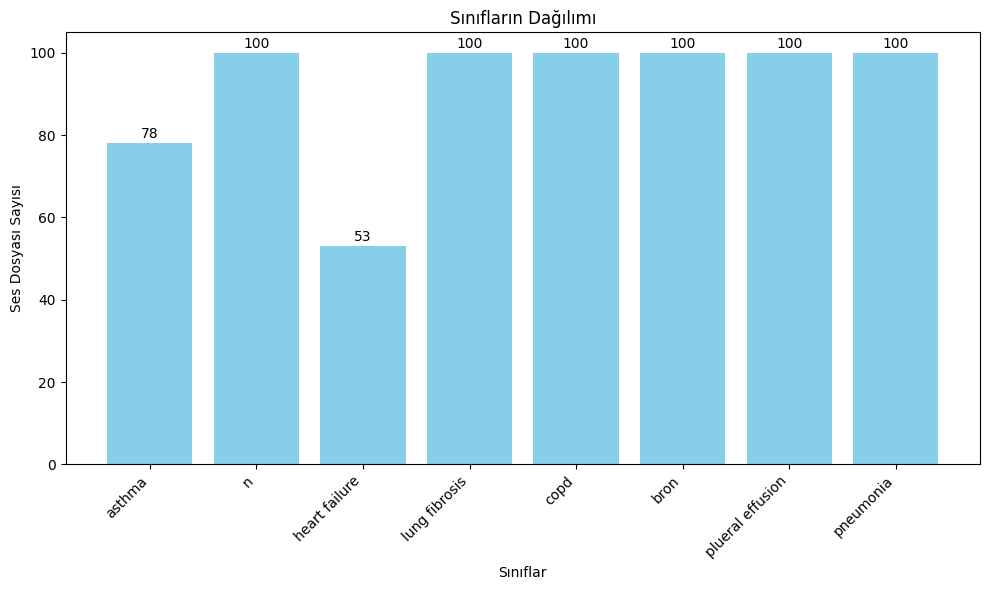

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


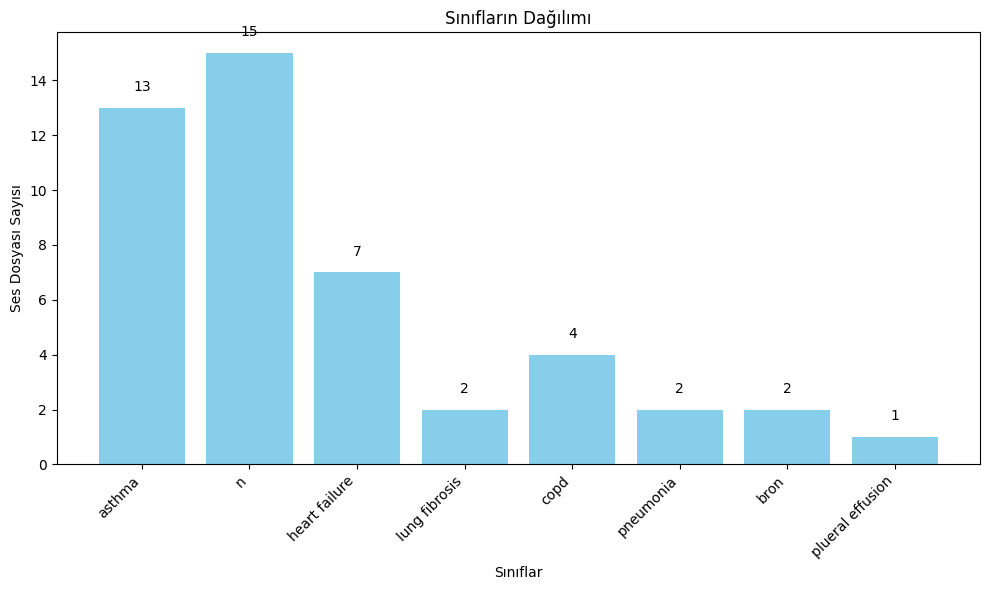

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


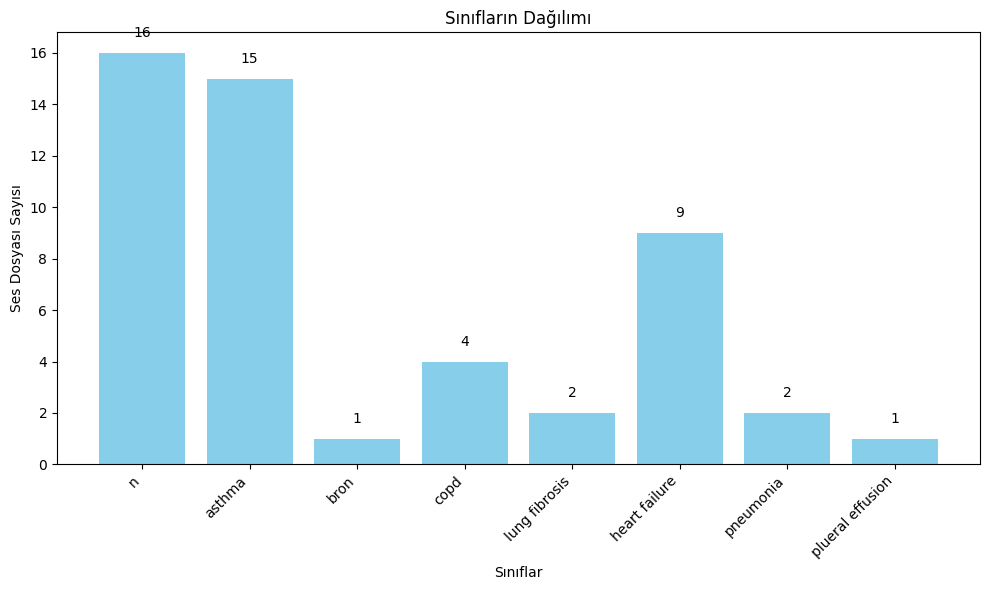

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


In [ ]:
import soundfile as sf

def augment_audio(input_path, output_path, rate=1.2, n_steps=4, noise_factor=0.005):
    y, sr = librosa.load(input_path)

    # Time Stretching
    y_stretched = librosa.effects.time_stretch(y, rate=rate)

    # Pitch Shifting
    y_pitch_shifted = librosa.effects.pitch_shift(y_stretched, sr=sr, n_steps=n_steps)

    # Add White Noise
    noise = np.random.normal(0, noise_factor, y_pitch_shifted.shape)
    y_noisy = y_pitch_shifted + noise

    # Kaydedin
    sf.write(output_path, y_noisy, sr)



In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
from collections import defaultdict
from glob import glob

# Sınıf isimleri dosya adından çıkarılmalı (örn. klasör içinde)
def get_class_name(file_name):
    # Örnek isim: DP20_Asthma and lung fibrosis,C,A R M,90,M.wav
    return file_name.split("_")[1].split(",")[0].strip().lower()

# Tüm train dosyalarını bul
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train"
train_files = glob(os.path.join(train_dir, "*.wav"))

# Sınıflara göre grupla
class_file_map = defaultdict(list)
for file in train_files:
    class_name = get_class_name(os.path.basename(file))
    class_file_map[class_name].append(file)

# Hedef sayıya göre eksik sınıfları tespit et
hedef_sayi = 100
minor_classes = {k: v for k, v in class_file_map.items() if len(v) < hedef_sayi}

print("Eksik sınıflar:")
for k, v in minor_classes.items():
    print(f"{k}: {len(v)} dosya")

# Augment fonksiyonu
def augment_and_save(file_path, save_dir, class_name, augment_index):
    y, sr = librosa.load(file_path, sr=None)
    y_aug = y.copy()

    mod = augment_index % 3
    if mod == 0:
        y_aug = librosa.effects.time_stretch(y_aug, rate=0.9 + 0.05 * np.random.rand())
    elif mod == 1:
        y_aug = librosa.effects.pitch_shift(y_aug, sr=sr, n_steps=np.random.uniform(-2, 2))
    else:
        y_aug = y_aug + 0.005 * np.random.randn(len(y_aug))

    base = os.path.basename(file_path).replace(".wav", f"_aug{augment_index}.wav")
    save_path = os.path.join(save_dir, base)
    sf.write(save_path, y_aug, sr)
    print(f"✔ Augment edildi: {save_path}")

# Her eksik sınıf için augment işlemi
for class_name, files in minor_classes.items():
    mevcut = len(files)
    eksik = hedef_sayi - mevcut
    print(f"\n📌 {class_name} sınıfı için {eksik} augment gerekli.")
    augment_index = 0
    while eksik > 0:
        for file_path in files:
            if eksik <= 0:
                break
            augment_and_save(file_path, train_dir, class_name, augment_index)
            eksik -= 1
            augment_index += 1


Eksik sınıflar:
asthma: 68 dosya
n: 74 dosya
heart failure: 38 dosya
lung fibrosis: 8 dosya
copd: 19 dosya
bron: 6 dosya
heart failure + lung fibrosis: 2 dosya
heart failure + copd: 4 dosya
plueral effusion: 4 dosya
pneumonia: 11 dosya
asthma and lung fibrosis: 1 dosya

📌 asthma sınıfı için 32 augment gerekli.
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train/BP3_Asthma,I E W,P L L R,50,F_aug0.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train/BP47_asthma,E W,P L M,60,M_aug1.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train/BP35_Asthma,E W,A R L,38,M_aug2.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train/BP65_asthma,E W,P R L ,60,F_aug3.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train/BP12_Asthma,E W,P L L,50,F_aug4.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/

In [ ]:
import os

train_files = os.listdir("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train")
augmented_files = [f for f in train_files if "_aug" in f]
print(f"Toplam augment edilmiş dosya sayısı: {len(augmented_files)}")


Toplam augment edilmiş dosya sayısı: 565


In [ ]:
import os

aug_files = [f for f in os.listdir("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train") if "_aug" in f]
print("Bulunan augment dosyası sayısı:", len(aug_files))
print("Örnek augment dosyalar:", aug_files[:5])


Bulunan augment dosyası sayısı: 564
Örnek augment dosyalar: ['DP86_N,N,P R U,68,F_aug1.wav', 'DP54_heart failure,Crep,P R L ,73,F_aug1.wav', 'BP35_Asthma,E W,A R L,38,M_aug1.wav', 'BP65_asthma,E W,P R L ,60,F_aug1.wav', 'DP22_BRON,Crep,P R U,24,M_aug1.wav']


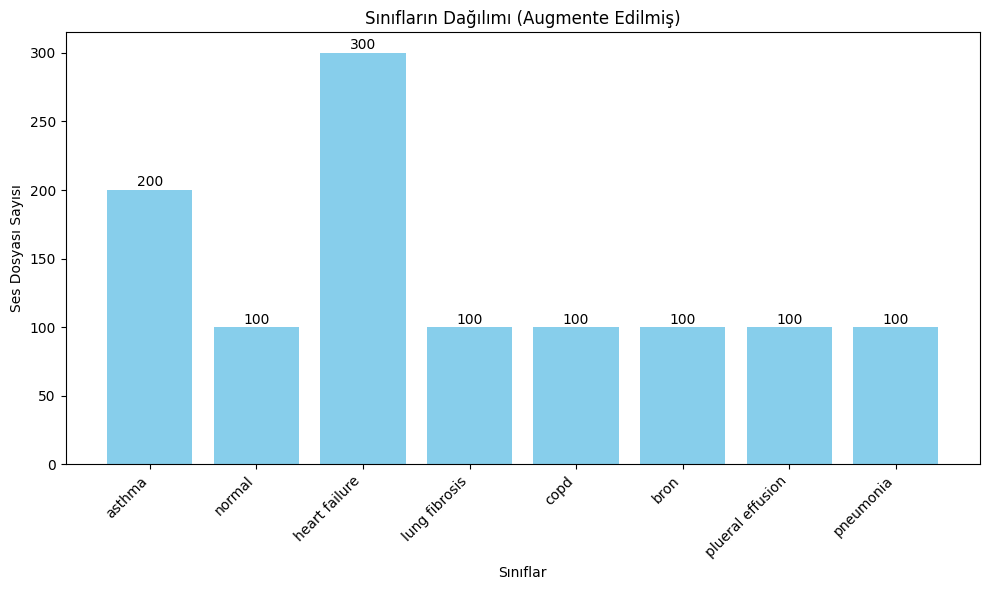

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train"

# Etiketleri saymak için sözlük
u_class_counts = {}

# Dosyaları dolaş
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        file_name = file_name.strip()

        try:
            # Etiketi çıkar (örnek: EP69_pneumonia,Bronchial,P R L ,64,M_aug2.wav -> pneumonia)
            raw_label = file_name.split('_')[1].split(',')[0].strip().lower()

            # Etiketi normalize et
            if 'asthma and lung fibrosis' in raw_label:
                label_name = 'asthma'
            elif 'heart failure + copd' in raw_label or 'heart failure + lung fibrosis' in raw_label:
                label_name = 'heart failure'
            elif 'asthma' in raw_label:
                label_name = 'asthma'
            elif 'bron' in raw_label:
                label_name = 'bron'
            elif 'copd' in raw_label:
                label_name = 'copd'
            elif 'heart failure' in raw_label:
                label_name = 'heart failure'
            elif 'lung fibrosis' in raw_label:
                label_name = 'lung fibrosis'
            elif 'pleural effusion' in raw_label or 'plueral effusion' in raw_label:
                label_name = 'plueral effusion'
            elif 'pneumonia' in raw_label:
                label_name = 'pneumonia'
            elif raw_label == 'n':
                label_name = 'normal'
            else:
                print(f"Bilinmeyen sınıf: {raw_label}")
                continue

            # Sözlüğe ekle
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

        except Exception as e:
            print(f"Hata: {file_name} -> {e}")

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı (Augmente Edilmiş)')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import os
import random
from glob import glob

train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train"
hedef_sayi = 100

# Etiketleme fonksiyonu: sadece asthma ve heart failure için uyarlanmış
def get_class_label(file_name):
    name = file_name.lower()
    if 'asthma and lung fibrosis' in name:
        return 'asthma'
    elif 'heart failure + copd' in name or 'heart failure + lung fibrosis' in name:
        return 'heart failure'
    elif 'asthma' in name:
        return 'asthma'
    elif 'heart failure' in name:
        return 'heart failure'
    else:
        return None

# asthma ve heart failure için dosyaları topla
asthma_files = []
heart_failure_files = []

for path in glob(os.path.join(train_dir, "*.wav")):
    class_label = get_class_label(os.path.basename(path))
    if class_label == 'asthma':
        asthma_files.append(path)
    elif class_label == 'heart failure':
        heart_failure_files.append(path)

# Silme fonksiyonu
def sil_augments(dosya_listesi, class_name):
    if len(dosya_listesi) > hedef_sayi:
        augment_files = [f for f in dosya_listesi if "_aug" in os.path.basename(f)]
        silinecek_sayi = len(dosya_listesi) - hedef_sayi

        if silinecek_sayi > len(augment_files):
            print(f"{class_name}: {silinecek_sayi} dosya silinmeli ama sadece {len(augment_files)} augment var!")
            silinecekler = augment_files
        else:
            silinecekler = random.sample(augment_files, silinecek_sayi)

        for f in silinecekler:
            os.remove(f)
        print(f"{class_name}: {len(silinecekler)} augment dosya silindi.")
    else:
        print(f"{class_name}: Silmeye gerek yok ({len(dosya_listesi)} dosya var).")

# Uygula
sil_augments(asthma_files, "asthma")
sil_augments(heart_failure_files, "heart failure")


asthma: 100 augment dosya silindi.
heart failure: 200 augment dosya silindi.


In [ ]:
# Augment edilmiş dosyaların bulunduğu dizin
augmented_directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train"

# Etiketleri saklayacak liste
labelss = []

# Dizin içindeki augment edilmiş dosyaları gez
for file_name in os.listdir(augmented_directory):
    if file_name.endswith(".wav"):  # Sadece wav dosyalarını al
        file_name = file_name.strip()  # Olası boşlukları temizle

        # Augment edilmiş dosyaların isimlerinde '_aug' olduğu için, bunu regex ile işleme alıyoruz
        match = re.match(
                r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)(?:_aug\d+)?(?:_aug\d+)?(?:_aug\d+)?\.wav$', file_name
            )

        if match:
            patient_id = match.group(1)
            diagnosis = match.group(2).strip()
            sound_type = match.group(3).strip()
            measurement_location = match.group(4).strip()
            age = int(match.group(5))
            gender = match.group(6)

            # Etiketler listesine ekle
            labelss.append({
                "file_name": file_name,
                "patient_id": patient_id,
                "diagnosis": diagnosis,
                "sound_type": sound_type,
                "measurement_location": measurement_location,
                "age": age,
                "gender": gender
            })
        else:
            print(f"No match for file: {file_name}")  # Regex'e uymayan dosyaları yazdır

# Etiketlerin çıktısını gözlemle
for label in labels:
    print(label)


asthma
normal
heart failure
lung fibrosis
copd
bron
plueral effusion
pneumonia


In [ ]:
from collections import Counter

# Örneğin, tüm etiketleri (sınıf adlarını) diagnosis alanından alıyorsan:
all_labels = [item['diagnosis'] for item in labelss]

# Sayıları hesapla
label_counts = Counter(all_labels)

# Yazdır
for label, count in label_counts.items():
    print(f"{label}: {count}")

Asthma: 45
asthma: 33
N: 100
heart failure: 45
Lung Fibrosis: 100
COPD: 89
BRON: 100
Heart Failure + Lung Fibrosis: 24
Heart Failure + COPD: 23
copd: 11
Plueral Effusion: 100
pneumonia: 100
Heart Failure: 8
Asthma and lung fibrosis: 22


In [ ]:
len(labelss)

800

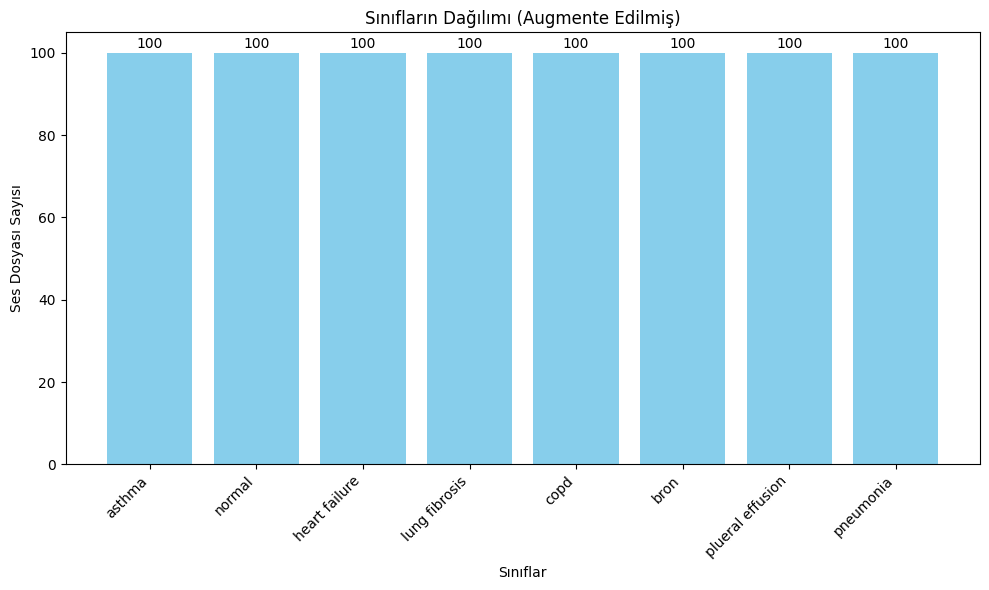

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train"

# Etiketleri saymak için sözlük
u_class_counts = {}

# Dosyaları dolaş
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        file_name = file_name.strip()

        try:
            # Etiketi çıkar (örnek: EP69_pneumonia,Bronchial,P R L ,64,M_aug2.wav -> pneumonia)
            raw_label = file_name.split('_')[1].split(',')[0].strip().lower()

            # Etiketi normalize et
            if 'asthma and lung fibrosis' in raw_label:
                label_name = 'asthma'
            elif 'heart failure + copd' in raw_label or 'heart failure + lung fibrosis' in raw_label:
                label_name = 'heart failure'
            elif 'asthma' in raw_label:
                label_name = 'asthma'
            elif 'bron' in raw_label:
                label_name = 'bron'
            elif 'copd' in raw_label:
                label_name = 'copd'
            elif 'heart failure' in raw_label:
                label_name = 'heart failure'
            elif 'lung fibrosis' in raw_label:
                label_name = 'lung fibrosis'
            elif 'pleural effusion' in raw_label or 'plueral effusion' in raw_label:
                label_name = 'plueral effusion'
            elif 'pneumonia' in raw_label:
                label_name = 'pneumonia'
            elif raw_label == 'n':
                label_name = 'normal'
            else:
                print(f"Bilinmeyen sınıf: {raw_label}")
                continue

            # Sözlüğe ekle
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

        except Exception as e:
            print(f"Hata: {file_name} -> {e}")

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı (Augmente Edilmiş)')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import os
import torch
import torchaudio
import numpy as np

max_len = 751

def normalize_label(raw_label):
    raw_label = raw_label.lower().strip()
    if 'asthma and lung fibrosis' in raw_label:
        return 'asthma'
    elif 'heart failure + copd' in raw_label or 'heart failure + lung fibrosis' in raw_label:
        return 'heart failure'
    elif 'asthma' in raw_label:
        return 'asthma'
    elif 'bron' in raw_label:
        return 'bron'
    elif 'copd' in raw_label:
        return 'copd'
    elif 'heart failure' in raw_label:
        return 'heart failure'
    elif 'lung fibrosis' in raw_label:
        return 'lung fibrosis'
    elif 'pleural effusion' in raw_label or 'plueral effusion' in raw_label:
        return 'plueral effusion'
    elif 'pneumonia' in raw_label:
        return 'pneumonia'
    elif raw_label == 'n':
        return 'normal'
    else:
        print(f"Bilinmeyen sınıf: {raw_label}")
        return None

def extract_label_from_filename(file_name):
    try:
        raw_label = file_name.split('_')[1].split(',')[0].strip()
        return normalize_label(raw_label)
    except IndexError:
        print(f"Dosya adı formatı uygun değil: {file_name}")
        return None

def extract_mfcc(file_path, max_len=max_len):
    waveform, sample_rate = torchaudio.load(file_path)

    mfcc_transform = torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=40,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )

    mfcc = mfcc_transform(waveform).squeeze(0)  # (40, time)

    if mfcc.shape[1] < max_len:
        pad_amount = max_len - mfcc.shape[1]
        mfcc = torch.nn.functional.pad(mfcc, (0, pad_amount))
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc.numpy()

# Verisetini yükle (otomatik max_len belirleme + padding)
def load_data_from_folder(folder_path, max_len=max_len):
    X = []
    y = []
    labels_set = set()

    # İlk olarak klasördeki dosyalar üzerinden etiketleri topla
    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is not None:
                labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print(f"Bulunan sınıflar ve indeksleri: {label2idx}")

    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is None:
                continue
            file_path = os.path.join(folder_path, filename)
            mfcc = extract_mfcc(file_path, max_len)
            X.append(mfcc)
            y.append(label2idx[label])

    return np.array(X), np.array(y), label2idx

# Kullanım
train_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train"
val_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val"
test_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test"

X_train, y_train, label2idx = load_data_from_folder(train_folder)
X_val, y_val, _ = load_data_from_folder(val_folder)
X_test, y_test, _ = load_data_from_folder(test_folder)

# CNN için kanal boyutu ekle (N, 40, 751, 1)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]


print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Val data shape: {X_val.shape}, Val labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")


Bulunan sınıflar ve indeksleri: {'asthma': 0, 'bron': 1, 'copd': 2, 'heart failure': 3, 'lung fibrosis': 4, 'normal': 5, 'plueral effusion': 6, 'pneumonia': 7}
Bulunan sınıflar ve indeksleri: {'asthma': 0, 'bron': 1, 'copd': 2, 'heart failure': 3, 'lung fibrosis': 4, 'normal': 5, 'plueral effusion': 6, 'pneumonia': 7}
Bulunan sınıflar ve indeksleri: {'asthma': 0, 'bron': 1, 'copd': 2, 'heart failure': 3, 'lung fibrosis': 4, 'normal': 5, 'plueral effusion': 6, 'pneumonia': 7}
Train data shape: (790, 40, 751, 1), Train labels shape: (790,)
Val data shape: (46, 40, 751, 1), Val labels shape: (46,)
Test data shape: (50, 40, 751, 1), Test labels shape: (50,)


In [ ]:
import os
import re

def get_labels_from_dir(directory):
    labels = []
    files = [f for f in os.listdir(directory) if f.endswith(".wav")]
    for file_name in files:
        match = re.match(
            r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)(?:_aug\d+)?(?:_aug\d+)?(?:_aug\d+)?(?:_aug\d+)?(?:_aug\d+)?\.wav$', file_name
        )
        if match:
            diagnosis = match.group(2).strip().lower()
            # Aynı etiket temizleme mantığını kullan
            if 'asthma and lung fibrosis' in diagnosis:
                cleaned_label = 'asthma'
            elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
                cleaned_label = 'heart failure'
            elif 'asthma' in diagnosis:
                cleaned_label = 'asthma'
            elif 'bron' in diagnosis:
                cleaned_label = 'bron'
            elif 'copd' in diagnosis:
                cleaned_label = 'copd'
            elif 'heart failure' in diagnosis:
                cleaned_label = 'heart failure'
            elif 'lung fibrosis' in diagnosis:
                cleaned_label = 'lung fibrosis'
            elif 'pleural effusion' in diagnosis or 'plueral effusion' in diagnosis:
                cleaned_label = 'plueral effusion'
            elif 'pneumonia' in diagnosis:
                cleaned_label = 'pneumonia'
            elif diagnosis == 'n':
                cleaned_label = 'normal'
            else:
                continue
            labels.append(cleaned_label)
        else:
            print(f"Regex'e uymayan dosya: {file_name}")
    return labels

train_labels = get_labels_from_dir("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train")
val_labels = get_labels_from_dir("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val")
test_labels = get_labels_from_dir("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test")

print(f"Train labels: {train_labels[:10]}")
print(f"Val labels: {val_labels[:10]}")
print(f"Test labels: {test_labels[:10]}")


Train labels: ['asthma', 'asthma', 'normal', 'heart failure', 'asthma', 'asthma', 'asthma', 'lung fibrosis', 'copd', 'bron']
Val labels: ['heart failure', 'asthma', 'normal', 'heart failure', 'lung fibrosis', 'heart failure', 'copd', 'pneumonia', 'asthma', 'copd']
Test labels: ['normal', 'asthma', 'bron', 'copd', 'lung fibrosis', 'normal', 'normal', 'normal', 'heart failure', 'copd']


In [ ]:
label_map = {
    'asthma': 0,
    'bron': 1,
    'copd': 2,
    'heart failure': 3,
    'lung fibrosis': 4,
    'normal': 5,
    'plueral effusion': 6,
    'pneumonia': 7
}

# Doğru isimleri kullan
y_train_int = np.array([label_map[label] for label in train_labels])
y_val_int = np.array([label_map[label] for label in val_labels])
y_test_int = np.array([label_map[label] for label in test_labels])

# One-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train_int, num_classes=len(label_map))
y_val = to_categorical(y_val_int, num_classes=len(label_map))
y_test = to_categorical(y_test_int, num_classes=len(label_map))


In [ ]:
print("Örnek sayısal etiketler:", y_train_int[:10])
print("One-hot etiketler:")
print(y_train[:2])

Örnek sayısal etiketler: [0 0 5 3 0 0 0 4 2 1]
One-hot etiketler:
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(40, 751, 1)),  # Buraya input_shape artık ayrı olarak yazılıyor
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')  # 8 sınıf
])

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 40, 751, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 40, 751, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 20, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 20, 375, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 20, 375, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 10, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 10, 187, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 10, 187, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 5, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 59520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │    15,237,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,333,000 (58.49 MB)

 Trainable params: 15,332,552 (58.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# EarlyStopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,         # 10 epoch boyunca iyileşme olmazsa dur
    restore_best_weights=True,
    verbose=1
)

# CNN sonuçları

In [ ]:
# Eğitim
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights  # sınıf dengesi sağlanıyor
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.2286 - loss: 11.7251 - val_accuracy: 0.2800 - val_loss: 2.2578
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.5626 - loss: 1.3172 - val_accuracy: 0.3000 - val_loss: 1.9431
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.6007 - loss: 1.1285 - val_accuracy: 0.3000 - val_loss: 1.8042
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.6425 - loss: 0.9955 - val_accuracy: 0.3000 - val_loss: 1.8677
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.7323 - loss: 0.7000 - val_accuracy: 0.3800 - val_loss: 1.8663
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.8240 - loss: 0.5258 - val_accuracy: 0.2200 - val_loss: 1.8342
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.8452 - loss: 0.4197 - val_accuracy: 0.4200 - val_loss: 1.6501
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.8388 - loss: 0.4333 - val_accuracy: 0.

In [ ]:
# Test seti üzerinde değerlendirme
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 357ms/step - accuracy: 0.9165 - loss: 0.7282
Test Loss: 0.6571
Test Accuracy: 0.9216


Başarı oranı (%92.16): Model, daha önce hiç görmediği test verisinin %92’sini doğru sınıflandırmış. Bu, genelleme başarısının yüksek olduğunu gösteriyor.

Loss (0.6571): Biraz yüksek ama bu genellikle çok sınıflı problemler ve dengesiz veri durumlarında olabilir. Accuracy ile birlikte değerlendirildiğinde kabul edilebilir.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 476ms/step
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         4
           3       0.91      1.00      0.95        10
           4       1.00      1.00      1.00         2
           5       0.83      0.94      0.88        16
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2

    accuracy                           0.92        51
   macro avg       0.84      0.85      0.85        51
weighted avg       0.91      0.92      0.91        51



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


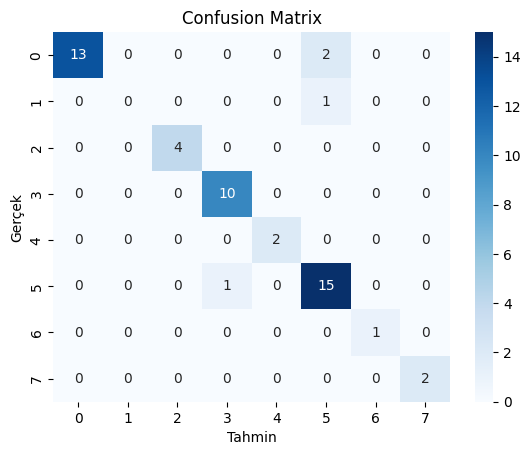

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Tahminler
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)  # Eğer y_test one-hot encoded ise

# Sınıflandırma raporu
print(classification_report(y_true, y_pred))

# Karışıklık matrisi
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()


Bulunan sınıflar ve indeksleri: {'asthma': 0, 'bron': 1, 'copd': 2, 'heart failure': 3, 'lung fibrosis': 4, 'normal': 5, 'plueral effusion': 6, 'pneumonia': 7}

In [ ]:
model.save("cnn_mfcc_model.keras")


In [ ]:
import os

# Modelinizi kaydettikten sonra
# model.save("cnn_mfcc_model.keras")

# Kaydedilen dosyanın varlığını kontrol et
if os.path.exists("cnn_mfcc_model.keras"):
    print("Model başarıyla kaydedildi: cnn_mfcc_model.keras")
else:
    print("Model dosyası bulunamadı.")

# Alternatif olarak, dizindeki tüm dosyaları listele
print("\nBulunan dosyalar:")
print(os.listdir())

Model başarıyla kaydedildi: cnn_mfcc_model.keras

Bulunan dosyalar:
['.config', 'cnn_mfcc_model.keras', '4sınıflı_best_model.keras', 'drive', '4_cnn_rnn_best_model.keras', '4sınıflıCNN.keras', 'sample_data']


# kfold CNN sonuçları

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import tensorflow as tf

# K değerini seç (örnek: 5)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Verilerin numpy formatında olduğunu varsayıyoruz:
# X.shape -> (n_samples, features...)
# y.shape -> (n_samples,)
# Eğer y one-hot encoded ise, önce argmax ile tekil hale getir:
# y_single = np.argmax(y, axis=1)  # Sadece one-hot için gerekliyse

fold_no = 1
for train_index, val_index in kfold.split(X, y):  # y one-hot değilse doğrudan kullanılabilir
    print(f"\n===== Fold {fold_no} =====")

    # Verileri ayır
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Modeli sıfırdan oluştur (her fold'da yeniden tanımlanmalı)
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=X.shape[1:]),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(len(np.unique(y)), activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',  # y one-hot değilse bunu kullan
                  metrics=['accuracy'])

    # EarlyStopping opsiyonel
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Eğitimi başlat
    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=50,
              batch_size=32,
              callbacks=[early_stopping],
              verbose=1)

    # Değerlendirme
    y_pred = model.predict(X_val)
    y_pred_labels = np.argmax(y_pred, axis=1)

    print("Classification Report:")
    print(classification_report(y_val, y_pred_labels))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred_labels))

    fold_no += 1



===== Fold 1 =====


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.2760 - loss: 22.2018 - val_accuracy: 0.7136 - val_loss: 0.8055
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8376 - loss: 0.4822 - val_accuracy: 0.8869 - val_loss: 0.4239
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9682 - loss: 0.1218 - val_accuracy: 0.9070 - val_loss: 0.4358
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9992 - loss: 0.0183 - val_accuracy: 0.9196 - val_loss: 0.3854
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9975 - loss: 0.0087 - val_accuracy: 0.8995 - val_loss: 0.4379
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9997 - loss: 0.0053 - val_accuracy: 0.9146 - val_loss: 0.4084
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.9146 - val_loss: 0.4311
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 1.0000 - loss: 9.8957e-04 - val_accuracy: 0.9171 - val_

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.2604 - loss: 17.1179 - val_accuracy: 0.6357 - val_loss: 1.2288
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7129 - loss: 0.9627 - val_accuracy: 0.8166 - val_loss: 0.5115
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9482 - loss: 0.1824 - val_accuracy: 0.8593 - val_loss: 0.6113
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9849 - loss: 0.0598 - val_accuracy: 0.8970 - val_loss: 0.4566
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9922 - loss: 0.0341 - val_accuracy: 0.8945 - val_loss: 0.4609
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9990 - loss: 0.0086 - val_accuracy: 0.8920 - val_loss: 0.4255
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9975 - loss: 0.0108 - val_accuracy: 0.8894 - val_loss: 0.4352
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9994 - loss: 0.0047 - val_accuracy: 0.8995 - val_loss

...

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.2964 - loss: 13.8343 - val_accuracy: 0.7085 - val_loss: 0.8924
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7543 - loss: 0.6553 - val_accuracy: 0.8266 - val_loss: 0.4728
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9346 - loss: 0.1937 - val_accuracy: 0.8869 - val_loss: 0.3603
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9764 - loss: 0.0878 - val_accuracy: 0.9246 - val_loss: 0.2788
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9962 - loss: 0.0194 - val_accuracy: 0.9221 - val_loss: 0.2938
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 0.9221 - val_loss: 0.2864
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9271 - val_loss: 0.2844
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 1.0000 - loss: 8.0118e-04 - val_accuracy: 0.9221 - val_

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.2445 - loss: 15.5119 - val_accuracy: 0.6709 - val_loss: 0.9488
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7910 - loss: 0.6441 - val_accuracy: 0.8266 - val_loss: 0.5080
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9404 - loss: 0.1870 - val_accuracy: 0.9045 - val_loss: 0.2759
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9899 - loss: 0.0573 - val_accuracy: 0.8995 - val_loss: 0.2577
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9972 - loss: 0.0187 - val_accuracy: 0.9347 - val_loss: 0.2204
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9979 - loss: 0.0088 - val_accuracy: 0.9347 - val_loss: 0.2308
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9967 - loss: 0.0138 - val_accuracy: 0.8794 - val_loss: 0.4356
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9958 - loss: 0.0155 - val_accuracy: 0.9020 - val_loss

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.3260 - loss: 10.9810 - val_accuracy: 0.7362 - val_loss: 0.8747
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8219 - loss: 0.5266 - val_accuracy: 0.8869 - val_loss: 0.3832
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9647 - loss: 0.1107 - val_accuracy: 0.8719 - val_loss: 0.3903
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9923 - loss: 0.0309 - val_accuracy: 0.9045 - val_loss: 0.3328
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9983 - loss: 0.0160 - val_accuracy: 0.9146 - val_loss: 0.2856
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9996 - loss: 0.0065 - val_accuracy: 0.9196 - val_loss: 0.3179
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.9221 - val_loss: 0.2877
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9146 - val_loss

Bulunan sınıflar ve indeksleri: {'asthma': 0, 'bron': 1, 'copd': 2, 'heart failure': 3, 'lung fibrosis': 4, 'normal': 5, 'plueral effusion': 6, 'pneumonia': 7}

In [ ]:
model.save('cnn_kfold_model.keras')


# CNN-RNN Hibrid


**CNN-RNN Hibrid**

In [ ]:
import os
import shutil
import re

# Ana dizin ve hedef klasör
source_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti"
target_dir = os.path.join(source_dir, "ikili-etiket")

# Hedef klasör yoksa oluştur
os.makedirs(target_dir, exist_ok=True)

# Alt dizinlerle birlikte tüm klasörleri tara
for root, dirs, files in os.walk(source_dir):
    for file_name in files:
        if file_name.endswith(".wav"):
            match = re.match(r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)\.wav$', file_name.strip())
            if match:
                diagnosis = match.group(2).strip().lower()

                if '+' in diagnosis or 'and' in diagnosis:
                    src_path = os.path.join(root, file_name)
                    dst_path = os.path.join(target_dir, file_name)

                    # Dosya zaten taşınmış mı kontrol et
                    if not os.path.exists(dst_path):
                        shutil.move(src_path, dst_path)
                        print(f"Taşındı: {file_name}")



Taşındı: BP4_Heart Failure + Lung Fibrosis ,I C,P L R,72,F.wav
Taşındı: BP5_Heart Failure + COPD,I C E W,P L R ,71,M.wav
Taşındı: BP20_Asthma and lung fibrosis,C,A R M,90,M.wav
Taşındı: BP7_Heart Failure + COPD,I C E W,P L R,65,M.wav
Taşındı: DP20_Asthma and lung fibrosis,C,A R M,90,M.wav
Taşındı: DP7_Heart Failure + COPD,I C E W,P L R,65,M.wav
Taşındı: DP5_Heart Failure + COPD,I C E W,P L R ,71,M.wav
Taşındı: EP5_Heart Failure + COPD,I C E W,P L R ,71,M.wav
Taşındı: EP4_Heart Failure + Lung Fibrosis ,I C,P L R,72,F.wav
Taşındı: EP20_Asthma and lung fibrosis,C,A R M,90,M.wav
Taşındı: DP4_Heart Failure + Lung Fibrosis ,I C,P L R,72,F.wav
Taşındı: EP7_Heart Failure + COPD,I C E W,P L R,65,M.wav


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import re
from collections import Counter

# Orijinal dosyaların bulunduğu klasör
original_path = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new"
val_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val_new"
test_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test_new"

# Oluşturulacak dizinleri hazırla
for directory in [train_dir, val_dir, test_dir]:
    os.makedirs(directory, exist_ok=True)

# Klasördeki tüm ses dosyalarını al
files = [f for f in os.listdir(original_path) if f.endswith(".wav")]

labels = []
processed_files = []

for file_name in files:
    match = re.match(
        r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)(?:_aug\d+)?\.wav$', file_name
    )
    if match:
        diagnosis = match.group(2).strip().lower()

        # Etiket temizleme
        if 'asthma and lung fibrosis' in diagnosis:
            cleaned_label = 'asthma'
        elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
            cleaned_label = 'heart failure'
        elif 'asthma' in diagnosis:
            cleaned_label = 'asthma'
        elif 'bron' in diagnosis:
            cleaned_label = 'bron'
        elif 'copd' in diagnosis:
            cleaned_label = 'copd'
        elif 'heart failure' in diagnosis:
            cleaned_label = 'heart failure'
        elif 'lung fibrosis' in diagnosis:
            cleaned_label = 'lung fibrosis'
        elif 'pleural effusion' in diagnosis or 'plueral effusion' in diagnosis:
            cleaned_label = 'plueral effusion'
        elif 'pneumonia' in diagnosis:
            cleaned_label = 'pneumonia'
        elif diagnosis == 'n':
            cleaned_label = 'normal'
        else:
            print(f"Bilinmeyen sınıf: {diagnosis} için dosya {file_name} atlanıyor.")
            continue

        labels.append(cleaned_label)
        processed_files.append(file_name)
    else:
        print(f"Regex'e uymayan dosya atlanıyor: {file_name}")

# Sınıf dağılımını kontrol et
label_counts = Counter(labels)
single_sample_classes = [label for label, count in label_counts.items() if count < 2]

if single_sample_classes:
    print(f"UYARI: Aşağıdaki sınıflarda 2'den az örnek var, stratifikasyon sorun yaratabilir: {single_sample_classes}")
    # Bu sınıfların dosyalarını istersen filtreleyebilirsin, burada stratify kullanacağız
    # Eğer sorun yaşanırsa stratify=None denenebilir.

try:
    # Train ve temp (val+test) olarak ayır
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        processed_files, labels, test_size=0.3, stratify=labels, random_state=42
    )

    # Temp'i val ve test olarak ayır
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
    )

except ValueError as e:
    print(f"HATA: Stratifikasyon ile ilgili problem oluştu: {e}")
    print("Tek örnekli sınıfları ya kaldırın ya da stratify=None ile tekrar deneyin.")
    exit()

print(f"Eğitim dosyası sayısı: {len(train_files)}")
print(f"Doğrulama dosyası sayısı: {len(val_files)}")
print(f"Test dosyası sayısı: {len(test_files)}")

# Dosyaları uygun klasörlere kopyala
for f in train_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(train_dir, f))
for f in val_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(val_dir, f))
for f in test_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(test_dir, f))


Eğitim dosyası sayısı: 226
Doğrulama dosyası sayısı: 49
Test dosyası sayısı: 49


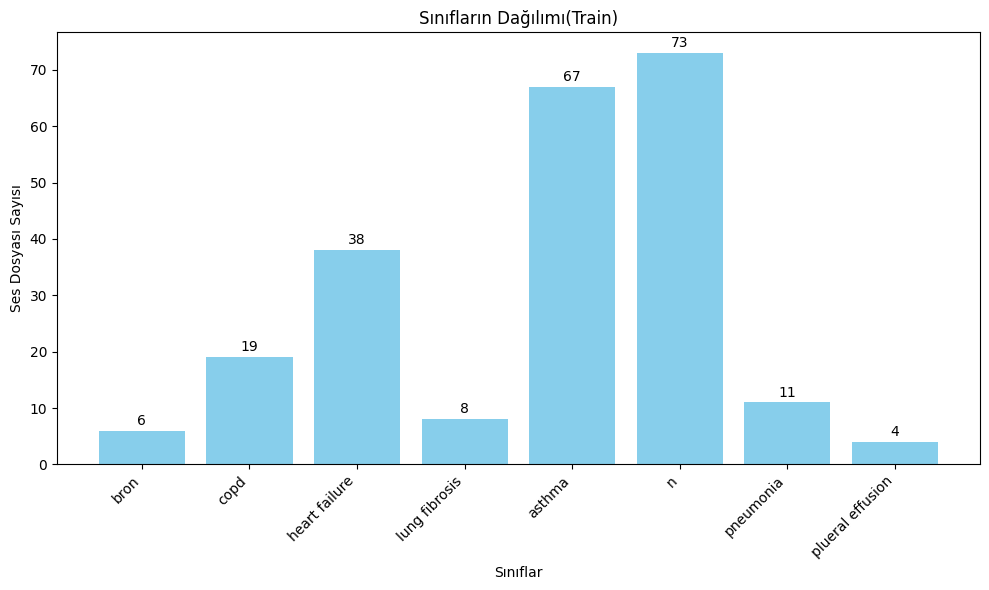

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı(Train)')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


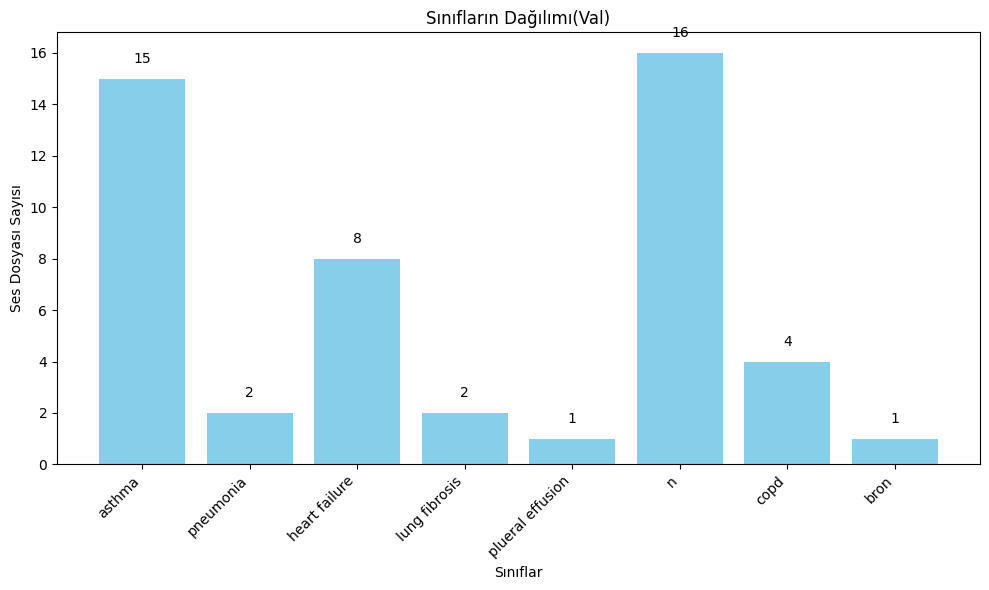

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val_new"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı(Val)')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


In [ ]:
# Sınıf dağılımını liste olarak yazdırma
print("Sınıf Dağılımı (Val seti):")
for sınıf, adet in u_class_counts.items():
    print(f"{sınıf}: {adet}")

Sınıf Dağılımı (Val seti):
asthma: 15
pneumonia: 2
heart failure: 8
lung fibrosis: 2
plueral effusion: 1
n: 16
copd: 4
bron: 1


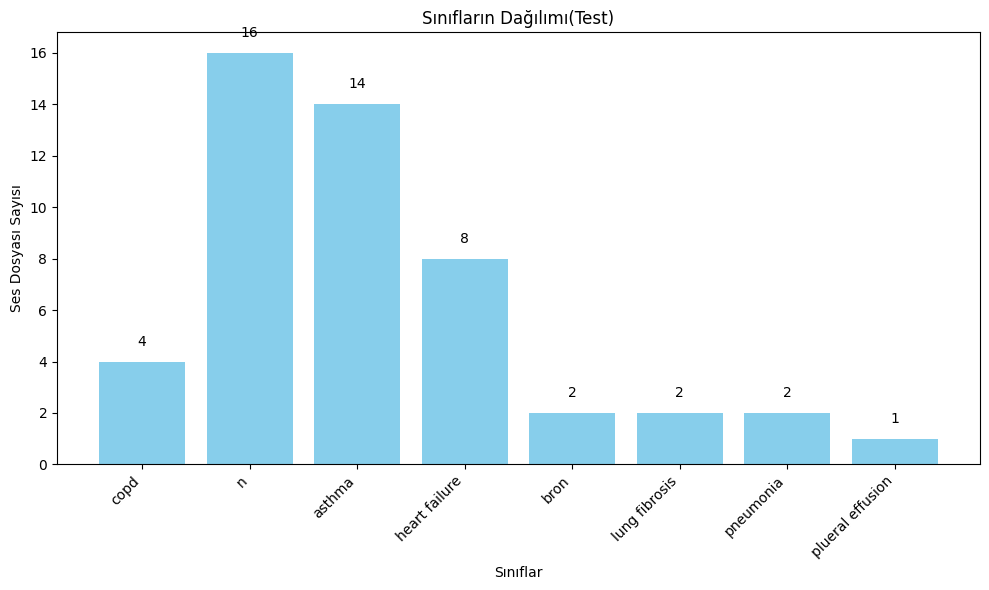

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test_new"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı(Test)')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


In [ ]:
# Sınıf dağılımını liste olarak yazdırma
print("Sınıf Dağılımı (Test seti):")
for sınıf, adet in u_class_counts.items():
    print(f"{sınıf}: {adet}")

Sınıf Dağılımı (Test seti):
copd: 4
n: 16
asthma: 14
heart failure: 8
bron: 2
lung fibrosis: 2
pneumonia: 2
plueral effusion: 1


In [ ]:
import soundfile as sf

def augment_audio(input_path, output_path, rate=1.2, n_steps=4, noise_factor=0.005):
    y, sr = librosa.load(input_path)

    # Time Stretching
    y_stretched = librosa.effects.time_stretch(y, rate=rate)

    # Pitch Shifting
    y_pitch_shifted = librosa.effects.pitch_shift(y_stretched, sr=sr, n_steps=n_steps)

    # Add White Noise
    noise = np.random.normal(0, noise_factor, y_pitch_shifted.shape)
    y_noisy = y_pitch_shifted + noise

    # Kaydedin
    sf.write(output_path, y_noisy, sr)


In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
from collections import defaultdict
from glob import glob

# Sınıf isimleri dosya adından çıkarılmalı (örn. klasör içinde)
def get_class_name(file_name):
    # Örnek isim: DP20_Asthma and lung fibrosis,C,A R M,90,M.wav
    return file_name.split("_")[1].split(",")[0].strip().lower()

# Tüm train dosyalarını bul
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new"
train_files = glob(os.path.join(train_dir, "*.wav"))

# Sınıflara göre grupla
class_file_map = defaultdict(list)
for file in train_files:
    class_name = get_class_name(os.path.basename(file))
    class_file_map[class_name].append(file)

# Hedef sayıya göre eksik sınıfları tespit et
hedef_sayi = 100
minor_classes = {k: v for k, v in class_file_map.items() if len(v) < hedef_sayi}

print("Eksik sınıflar:")
for k, v in minor_classes.items():
    print(f"{k}: {len(v)} dosya")

# Augment fonksiyonu
def augment_and_save(file_path, save_dir, class_name, augment_index):
    y, sr = librosa.load(file_path, sr=None)
    y_aug = y.copy()

    mod = augment_index % 3
    if mod == 0:
        y_aug = librosa.effects.time_stretch(y_aug, rate=0.9 + 0.05 * np.random.rand())
    elif mod == 1:
        y_aug = librosa.effects.pitch_shift(y_aug, sr=sr, n_steps=np.random.uniform(-2, 2))
    else:
        y_aug = y_aug + 0.005 * np.random.randn(len(y_aug))

    base = os.path.basename(file_path).replace(".wav", f"_aug{augment_index}.wav")
    save_path = os.path.join(save_dir, base)
    sf.write(save_path, y_aug, sr)
    print(f"✔ Augment edildi: {save_path}")

# Her eksik sınıf için augment işlemi
for class_name, files in minor_classes.items():
    mevcut = len(files)
    eksik = hedef_sayi - mevcut
    print(f"\n📌 {class_name} sınıfı için {eksik} augment gerekli.")
    augment_index = 0
    while eksik > 0:
        for file_path in files:
            if eksik <= 0:
                break
            augment_and_save(file_path, train_dir, class_name, augment_index)
            eksik -= 1
            augment_index += 1


Eksik sınıflar:
bron: 6 dosya
copd: 19 dosya
heart failure: 38 dosya
lung fibrosis: 8 dosya
asthma: 67 dosya
n: 73 dosya
pneumonia: 11 dosya
plueral effusion: 4 dosya

📌 bron sınıfı için 94 augment gerekli.
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new/EP21_BRON,Crep,P R L ,20,M_aug0.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new/DP21_BRON,Crep,P R L ,20,M_aug1.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new/EP22_BRON,Crep,P R U,24,M_aug2.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new/DP22_BRON,Crep,P R U,24,M_aug3.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new/BP21_BRON,Crep,P R L ,20,M_aug4.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new/BP22_BRON,Crep,P R U,24,M_aug5.wav
✔ Augment edildi: /content/drive/My Drive/Cola

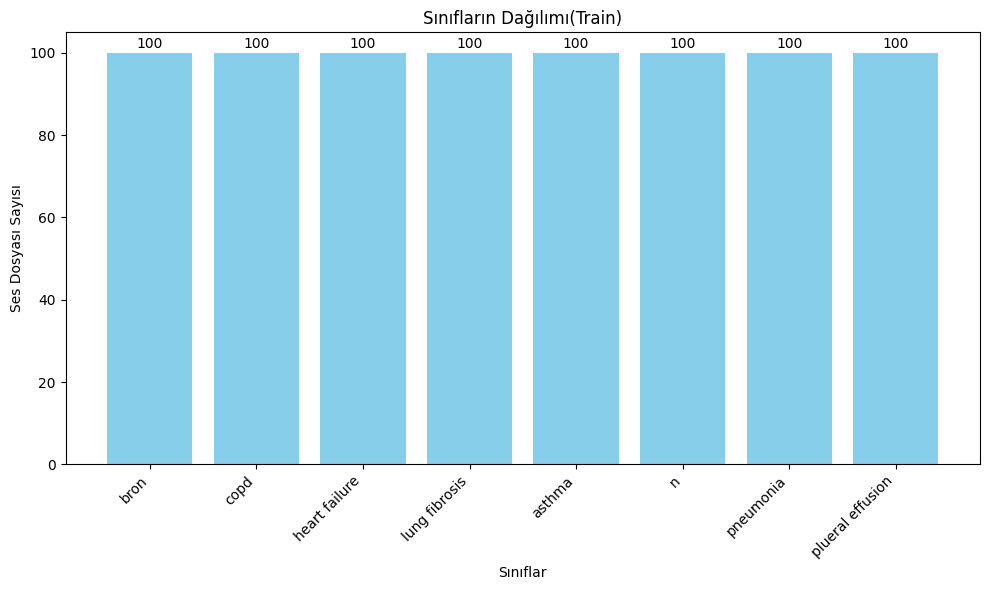

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı(Train)')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


In [ ]:
import os
import torch
import torchaudio
import numpy as np

max_len = 751

def normalize_label(raw_label):
    raw_label = raw_label.lower().strip()
    if 'asthma and lung fibrosis' in raw_label:
        return 'asthma'
    elif 'heart failure + copd' in raw_label or 'heart failure + lung fibrosis' in raw_label:
        return 'heart failure'
    elif 'asthma' in raw_label:
        return 'asthma'
    elif 'bron' in raw_label:
        return 'bron'
    elif 'copd' in raw_label:
        return 'copd'
    elif 'heart failure' in raw_label:
        return 'heart failure'
    elif 'lung fibrosis' in raw_label:
        return 'lung fibrosis'
    elif 'pleural effusion' in raw_label or 'plueral effusion' in raw_label:
        return 'plueral effusion'
    elif 'pneumonia' in raw_label:
        return 'pneumonia'
    elif raw_label == 'n':
        return 'normal'
    else:
        print(f"Bilinmeyen sınıf: {raw_label}")
        return None

def extract_label_from_filename(file_name):
    try:
        raw_label = file_name.split('_')[1].split(',')[0].strip()
        return normalize_label(raw_label)
    except IndexError:
        print(f"Dosya adı formatı uygun değil: {file_name}")
        return None

def extract_mfcc(file_path, max_len=max_len):
    waveform, sample_rate = torchaudio.load(file_path)

    mfcc_transform = torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=40,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )

    mfcc = mfcc_transform(waveform).squeeze(0)  # (40, time)

    if mfcc.shape[1] < max_len:
        pad_amount = max_len - mfcc.shape[1]
        mfcc = torch.nn.functional.pad(mfcc, (0, pad_amount))
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc.numpy()

# Verisetini yükle (otomatik max_len belirleme + padding)
def load_data_from_folder(folder_path, max_len=max_len):
    X = []
    y = []
    labels_set = set()

    # İlk olarak klasördeki dosyalar üzerinden etiketleri topla
    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is not None:
                labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print(f"Bulunan sınıflar ve indeksleri: {label2idx}")

    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is None:
                continue
            file_path = os.path.join(folder_path, filename)
            mfcc = extract_mfcc(file_path, max_len)
            X.append(mfcc)
            y.append(label2idx[label])

    return np.array(X), np.array(y), label2idx

# Kullanım
train_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train_new"
val_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val_new"
test_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test_new"

X_train, y_train, label2idx = load_data_from_folder(train_folder)
X_val, y_val, _ = load_data_from_folder(val_folder)
X_test, y_test, _ = load_data_from_folder(test_folder)

# CNN için kanal boyutu ekle (N, 40, 751, 1)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]


print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Val data shape: {X_val.shape}, Val labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

Bulunan sınıflar ve indeksleri: {'asthma': 0, 'bron': 1, 'copd': 2, 'heart failure': 3, 'lung fibrosis': 4, 'normal': 5, 'plueral effusion': 6, 'pneumonia': 7}
Bulunan sınıflar ve indeksleri: {'asthma': 0, 'bron': 1, 'copd': 2, 'heart failure': 3, 'lung fibrosis': 4, 'normal': 5, 'plueral effusion': 6, 'pneumonia': 7}
Bulunan sınıflar ve indeksleri: {'asthma': 0, 'bron': 1, 'copd': 2, 'heart failure': 3, 'lung fibrosis': 4, 'normal': 5, 'plueral effusion': 6, 'pneumonia': 7}
Train data shape: (800, 40, 751, 1), Train labels shape: (800,)
Val data shape: (49, 40, 751, 1), Val labels shape: (49,)
Test data shape: (49, 40, 751, 1), Test labels shape: (49,)


In [ ]:
label_map = {
    'asthma': 0,
    'bron': 1,
    'copd': 2,
    'heart failure': 3,
    'lung fibrosis': 4,
    'normal': 5,
    'plueral effusion': 6,
    'pneumonia': 7
}

def load_data_from_folder(folder_path, max_len=max_len):
    X = []
    y = []

    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is None:
                continue
            if label not in label_map:
                print(f"Etiket label_map içinde değil: {label}")
                continue
            file_path = os.path.join(folder_path, filename)
            mfcc = extract_mfcc(file_path, max_len)
            X.append(mfcc)
            y.append(label_map[label])

    return np.array(X), np.array(y)


In [ ]:
X_train, y_train = load_data_from_folder(train_folder)
X_val, y_val = load_data_from_folder(val_folder)
X_test, y_test = load_data_from_folder(test_folder)

# Kanal boyutu ekle (CNN için)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

from tensorflow.keras.utils import to_categorical
num_classes = len(label_map)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(f"Train X: {X_train.shape}, y: {y_train_cat.shape}")
print(f"Val X: {X_val.shape}, y: {y_val_cat.shape}")
print(f"Test X: {X_test.shape}, y: {y_test_cat.shape}")


Train X: (800, 40, 751, 1), y: (800, 8)
Val X: (49, 40, 751, 1), y: (49, 8)
Test X: (49, 40, 751, 1), y: (49, 8)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.layers import Flatten, Dense

num_classes = len(label2idx)  # Sınıf sayısı

input_shape = X_train.shape[1:]  # (40, 751, 1)

model = Sequential()

model.add(Input(shape=input_shape))  # Giriş şekli burada belirtiliyor

model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))  # Çıkış şekli: (20, 375, 32)

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))  # Çıkış şekli: (10, 187, 64)

model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))  # Çıkış şekli: (5, 93, 128)

#RNN Modeli
model.add(Reshape((5*93, 128)))  # (batch, 465, 128)

model.add(GRU(128, return_sequences=False))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(num_classes, activation='softmax'))

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 40, 751, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 40, 751, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 20, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 20, 375, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 20, 375, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 10, 187, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 10, 187, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 5, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 465, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,416 (786.78 KB)

 Trainable params: 200,968 (785.03 KB)

 Non-trainable params: 448 (1.75 KB)

# CNN-RNN sonuçları

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbackler
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,          # 10 epoch boyunca val_loss iyileşmezse durdur
    restore_best_weights=True
)

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)



reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Öğrenme oranını 0.5 ile çarp
    patience=5,           # 5 epoch boyunca iyileşme olmazsa
    min_lr=1e-6,
    verbose=1
)

# Hiperparametreler
batch_size = 32
epochs = 100
learning_rate = 0.001

# Optimizer ( Adam)
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Modeli eğit
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=2
)


Epoch 1/100

Epoch 1: val_loss improved from inf to 2.02261, saving model to best_model.keras
25/25 - 108s - 4s/step - accuracy: 0.1925 - loss: 1.9266 - val_accuracy: 0.0816 - val_loss: 2.0226 - learning_rate: 1.0000e-03
Epoch 2/100

Epoch 2: val_loss did not improve from 2.02261
25/25 - 129s - 5s/step - accuracy: 0.2300 - loss: 1.8610 - val_accuracy: 0.3061 - val_loss: 2.0289 - learning_rate: 1.0000e-03
Epoch 3/100

Epoch 3: val_loss did not improve from 2.02261
25/25 - 144s - 6s/step - accuracy: 0.2125 - loss: 1.8626 - val_accuracy: 0.2653 - val_loss: 2.0848 - learning_rate: 1.0000e-03
Epoch 4/100

Epoch 4: val_loss did not improve from 2.02261
25/25 - 140s - 6s/step - accuracy: 0.2763 - loss: 1.8355 - val_accuracy: 0.1020 - val_loss: 2.1337 - learning_rate: 1.0000e-03
Epoch 5/100

Epoch 5: val_loss improved from 2.02261 to 1.98419, saving model to best_model.keras
25/25 - 142s - 6s/step - accuracy: 0.2550 - loss: 1.8145 - val_accuracy: 0.1633 - val_loss: 1.9842 - learning_rate: 1.00

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Sınıf indeksleri (örneğin: [0,1,2,...])
classes = np.unique(y_train)

# Sınıf ağırlıklarını hesapla
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Sözlük formatına dönüştür
class_weights_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weights_dict)

# Modeli eğit
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    class_weight=class_weights_dict,
    verbose=2
)


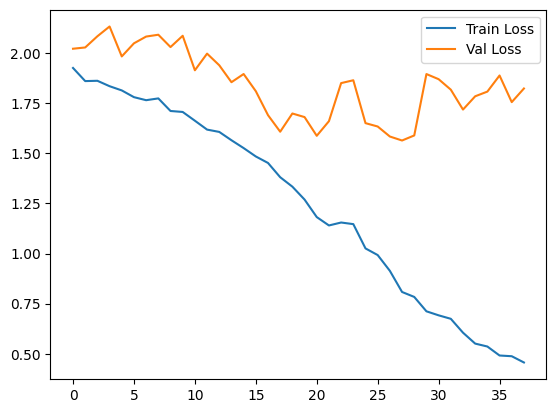

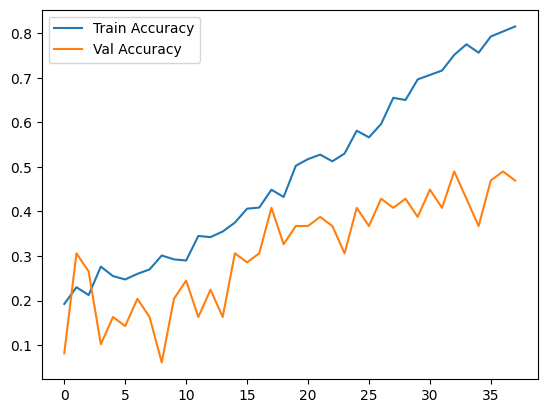

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()


# 4 sınıflı CNN

In [ ]:
# Gerçek diagnosis etiketlerini çıkar
labels = []
processed_files = []

directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"

for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):  # Sadece wav dosyalarını al
        file_name = file_name.strip()  # Olası boşlukları temizle
        match = re.match(
                r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)\.wav$', file_name
            )
    if match:
        diagnosis = match.group(2).strip().lower()

        # Önce diagnosis etiketini normalize et
        if 'asthma and lung fibrosis' in diagnosis:
            cleaned_label = 'asthma'
        elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
            cleaned_label = 'heart failure'
        elif 'asthma' in diagnosis:
            cleaned_label = 'asthma'
        elif 'copd' in diagnosis:
            cleaned_label = 'copd'
        elif 'heart failure' in diagnosis:
            cleaned_label = 'heart failure'
        elif diagnosis == 'n':
            cleaned_label = 'normal'
        else:
            # Burada artık sadece 4 sınıf dışındakileri atlıyoruz
            continue  # asthma, normal, copd, heart failure dışında kalanlar atlanır

        # Sadece bu dört sınıfa ait örnekleri ekle
        if cleaned_label in ['asthma', 'normal', 'copd', 'heart failure']:
            labels.append(cleaned_label)
            processed_files.append(file_name)
    else:
        print(f"Regex'e uymayan dosya atlanıyor: {file_name}")

print(processed_files)
print(labels)
print(len(processed_files), len(labels))


['BP109_N,N,P L M,26,M.wav', 'BP107_Asthma,E W,P L U,59,F.wav', 'BP108_COPD,E W,P R L ,63,M.wav', 'BP102_N,N,P L L,41,M.wav', 'BP101_Asthma,E W,P L M,12,F.wav', 'BP103_N,N,P R U,81,F.wav', 'BP106_Asthma,E W,P L U,45,F.wav', 'BP104_Asthma,E W,P L U,45,F.wav', 'BP100_N,N,P R M,70,F.wav', 'BP93_N,N,P R M,75,M.wav', 'BP27_asthma,E W,P R M,53,F.wav', 'BP89_N,N,P L M,70,M.wav', 'BP71_N,N,P R U,36,M.wav', 'BP33_Asthma,E W,P R M,43,F.wav', 'BP95_N,N,P L M,18,M.wav', 'BP32_N,N,A R L,30,M.wav', 'BP42_heart failure,Crep,P L L,56,M.wav', 'BP13_Heart Failure,C,P L L,55,M.wav', 'BP45_heart failure,Crep,P R L ,30,M.wav', 'BP61_COPD,E W,P R L ,53,M.wav', 'BP94_N,N,P L L,24,M.wav', 'BP67_heart failure,Crep,P R L ,24,F.wav', 'DP16_heart failure,C,P R U,56,M.wav', 'BP24_heart failure,Crep,P R L ,76,F.wav', 'BP57_COPD,E W,P R L ,42,M.wav', 'BP35_Asthma,E W,A R L,38,M.wav', 'DP107_Asthma,E W,P L U,59,F.wav', 'DP10_Asthma,E W,P R U,59,M.wav', 'BP90_heart failure,Crep,P L M,74,F.wav', 'BP79_asthma,E W,A R U,

In [ ]:
import os
import shutil
import re
from sklearn.model_selection import train_test_split
from collections import Counter

# Orijinal ses dosyalarının bulunduğu klasör
original_path = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"

# Hedef klasörler
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
val_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"

# Hedef klasörleri oluştur
for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Filtreleme
labels = []
processed_files = []

for file_name in os.listdir(original_path):
    if file_name.endswith(".wav"):
        file_name = file_name.strip()
        match = re.match(r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)(?:_aug\d+)?\.wav$', file_name)
        if match:
            diagnosis = match.group(2).strip().lower()

            # Etiketleri normalize et
            if 'asthma and lung fibrosis' in diagnosis:
                cleaned_label = 'asthma'
            elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
                cleaned_label = 'heart failure'
            elif 'asthma' in diagnosis:
                cleaned_label = 'asthma'
            elif 'copd' in diagnosis:
                cleaned_label = 'copd'
            elif 'heart failure' in diagnosis:
                cleaned_label = 'heart failure'
            elif diagnosis == 'n':
                cleaned_label = 'normal'
            else:
                continue

            if cleaned_label in ['asthma', 'normal', 'copd', 'heart failure']:
                processed_files.append(file_name)
                labels.append(cleaned_label)
        else:
            print(f"Regex'e uymayan dosya atlanıyor: {file_name}")

# Stratify için yeterli örneğe sahip olmayan sınıfları kontrol et
label_counts = Counter(labels)
low_sample_classes = [label for label, count in label_counts.items() if count < 2]

if low_sample_classes:
    print(f"Uyarı: Yetersiz örnek sayısı olan sınıflar: {low_sample_classes}")
    # Bu sınıfları çıkart
    filtered_files = []
    filtered_labels = []
    for f, l in zip(processed_files, labels):
        if l not in low_sample_classes:
            filtered_files.append(f)
            filtered_labels.append(l)
else:
    filtered_files = processed_files
    filtered_labels = labels

# Train / Val / Test bölmesi
train_files, temp_files, train_labels, temp_labels = train_test_split(
    filtered_files, filtered_labels, test_size=0.3, stratify=filtered_labels, random_state=42
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Eğitim dosyası sayısı: {len(train_files)}")
print(f"Doğrulama dosyası sayısı: {len(val_files)}")
print(f"Test dosyası sayısı: {len(test_files)}")

# Dosyaları kopyala
for f in train_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(train_dir, f))
for f in val_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(val_dir, f))
for f in test_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(test_dir, f))


Eğitim dosyası sayısı: 197
Doğrulama dosyası sayısı: 42
Test dosyası sayısı: 43


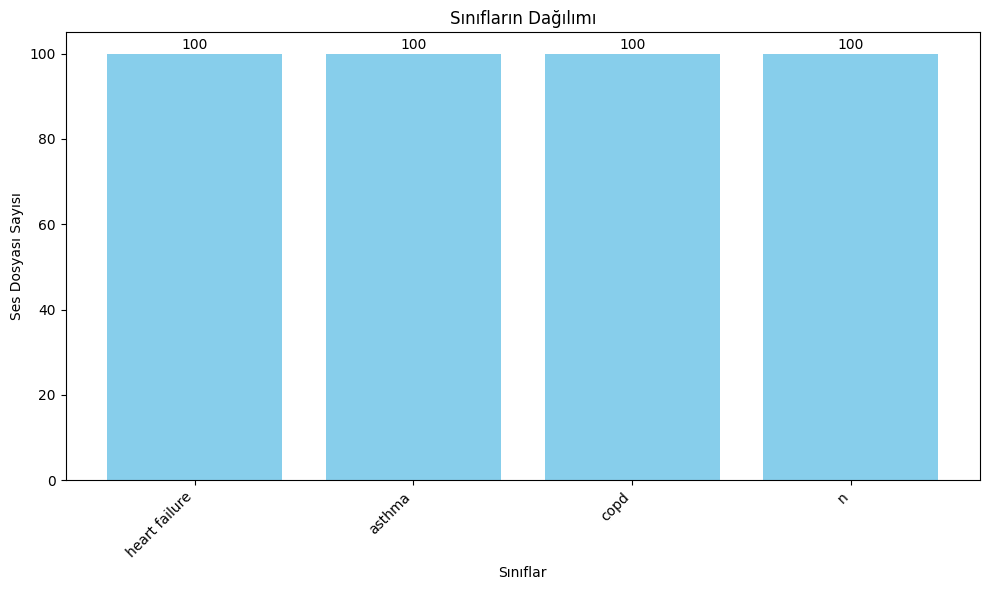

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


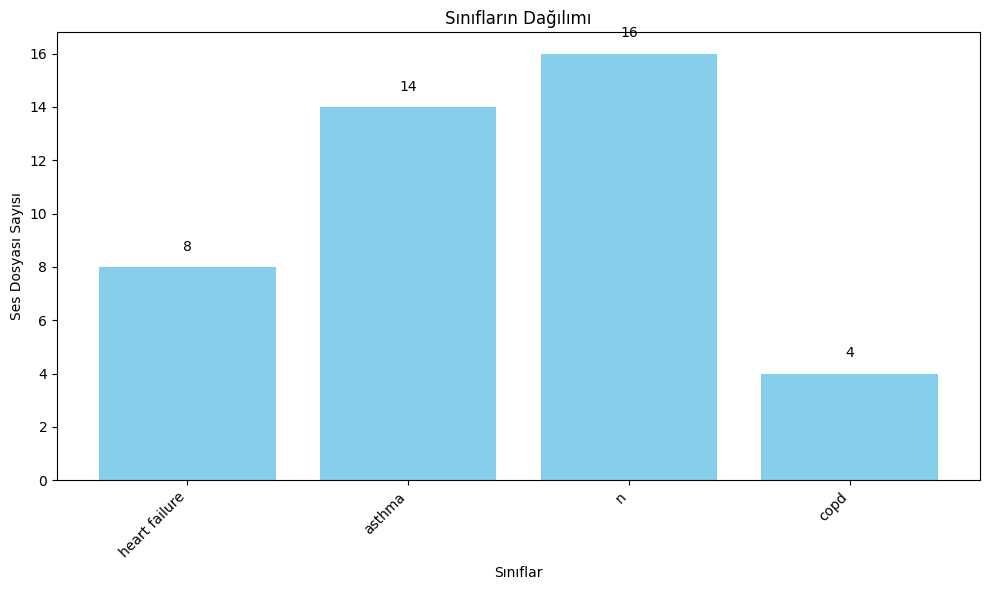

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


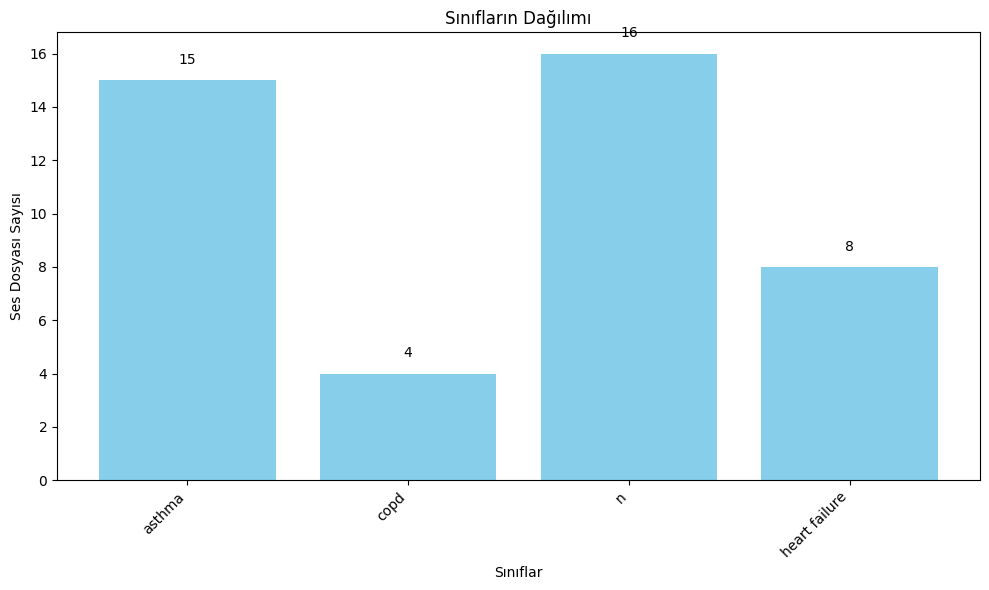

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"

# Sınıf etiketleri ve dosya sayılarını saklamak için sözlük
u_class_counts = {}

# Etiketleme işlemi
label = [x.lower().strip() for x in diagnoses]  # Küçük harf ve boşluk temizliği

# Etiketlerin düzenlenmesi
for i in range(len(label)):
    # Kombinasyon hastalık adları
    if 'asthma and lung fibrosis' in label[i]:
        label[i] = 'asthma'
    elif 'heart failure + copd' in label[i] or 'heart failure + lung fibrosis' in label[i]:
        label[i] = 'heart failure'

    elif 'asthma' in label[i]:
        label[i] = 'asthma'
    elif 'bron' in label[i]:
        label[i] = 'bron'
    elif 'copd' in label[i]:
        label[i] = 'copd'
    elif 'heart failure' in label[i]:
        label[i] = 'heart failure'
    elif 'lung fibrosis' in label[i]:
        label[i] = 'lung fibrosis'
    elif 'pleural effusion' in label[i] or 'plueral effusion' in label[i]:
        label[i] = 'plueral effusion'
    elif 'pneumonia' in label[i]:
        label[i] = 'pneumonia'
    elif label[i] == 'n':
        continue
    else:
        print(f"Bilinmeyen sınıf: {label[i]}")
        continue

# Ses dosyalarını ve etiketlerini yükle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        # Dosya adından etiketi çıkar (örnek: 'EP69_pneumonia,Bronchial,P R L ,64,M.wav' -> 'pneumonia')
        file_label = file_name.split('_')[1].split(',')[0].strip().lower()

        # Etiketi düzenle
        if file_label in label:
            label_name = label[label.index(file_label)]

            # Etiketi sözlüğe ekle veya sayacı artır
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')  # Etiketlerin okunabilirliği için döndürme
plt.tight_layout()  # Grafik öğelerinin üst üste binmesini önleme
plt.show()


bu bölüm alternatif çalıştırmadım!

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
from collections import defaultdict
from glob import glob
import numba # numba'yı import et

# Sınıf isimleri dosya adından çıkarılmalı (örn. klasör içinde)
def get_class_name(file_name):
    # Örnek isim: DP20_Asthma and lung fibrosis,C,A R M,90,M.wav
    # Augmente edilmiş dosya isimlerini de dikkate alacak şekilde regex kullanmak daha güvenli olabilir,
    # ancak bu basit ayrıştırma mevcut dosya formatı için çalışabilir.
    # Eğer format değişirse veya daha karmaşık hale gelirse, burası güncellenmelidir.
    parts = os.path.basename(file_name).split("_")
    if len(parts) > 1:
        diagnosis_part = parts[1].split(",")[0].strip().lower()
        # Burada label normalize etme mantığınızı ekleyebilirsiniz
        if 'asthma and lung fibrosis' in diagnosis_part:
            return 'asthma'
        elif 'heart failure + copd' in diagnosis_part or 'heart failure + lung fibrosis' in diagnosis_part:
            return 'heart failure'
        elif 'asthma' in diagnosis_part:
            return 'asthma'
        elif 'bron' in diagnosis_part:
            return 'bron'
        elif 'copd' in diagnosis_part:
            return 'copd'
        elif 'heart failure' in diagnosis_part:
            return 'heart failure'
        elif 'lung fibrosis' in diagnosis_part:
            return 'lung fibrosis'
        elif 'pleural effusion' in diagnosis_part or 'plueral effusion' in diagnosis_part:
            return 'plueral effusion'
        elif diagnosis_part == 'n':
            return 'normal'
        else:
            # Bilinmeyen sınıfları ele al veya atla
            # print(f"Bilinmeyen sınıf tespit edildi (get_class_name): {diagnosis_part} in file {file_name}")
            return None # Bilinmeyen sınıfları None olarak döndür
    return None # Geçersiz dosya formatı için None döndür

# Tüm train dosyalarını bul
# train_dir'i doğru klasör yoluyla güncelleyin (örn. train4)
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
train_files = glob(os.path.join(train_dir, "*.wav"))

# Sınıflara göre grupla (sadece geçerli sınıfları dahil et)
class_file_map = defaultdict(list)
valid_classes = {'asthma', 'normal', 'copd', 'heart failure'} # İşlem yapmak istediğiniz sınıflar
for file in train_files:
    class_name = get_class_name(file) # get_class_name dosyanın tam yolunu almalı
    if class_name in valid_classes: # Sadece işlemek istediğiniz sınıfları dahil edin
        class_file_map[class_name].append(file)
    #else:
        #print(f"Dosya '{os.path.basename(file)}' için sınıf '{class_name}' atlanıyor.")


# Hedef sayıya göre eksik sınıfları tespit et
hedef_sayi = 100
# Sadece train4'te bulunan ve hedef sayıdan az olan sınıfları işleyin
minor_classes = {k: v for k, v in class_file_map.items() if len(v) < hedef_sayi}


print("Eksik sınıflar (augment edilecekler):")
for k, v in minor_classes.items():
    print(f"{k}: {len(v)} dosya")

# Augment fonksiyonu
def augment_and_save(file_path, save_dir, augment_index): # class_name parametresi kullanılmıyor
    try:
        # Numba önbelleğini devre dışı bırakmayı dene
        # Bu, bazı Numba derleme hatalarını önlemeye yardımcı olabilir.
        # Geçici olarak Numba'nın derleme önbelleğini kapatıyoruz.
        # Bu, ilk kez çalıştırıldığında biraz daha uzun sürebilir.
        with numba.config.disable_compile_cache():
             y, sr = librosa.load(file_path, sr=None)

        y_aug = y.copy()

        mod = augment_index % 3
        if mod == 0:
            # Time Stretching: 0.9 ile 0.95 arasında rastgele hız
            rate = 0.9 + 0.05 * np.random.rand()
            # librosa.effects.time_stretch, sabit hızlı streching yapar.
            y_stretched = librosa.effects.time_stretch(y_aug, rate=rate, leave_length=len(y_aug))
            y_aug = y_stretched
        elif mod == 1:
            # Pitch Shifting: -2 ile 2 yarım ton arasında rastgele kaydırma
            n_steps = np.random.uniform(-2, 2)
            y_pitch_shifted = librosa.effects.pitch_shift(y_aug, sr=sr, n_steps=n_steps)
            y_aug = y_pitch_shifted
        else:
            # Add White Noise
            noise_factor = 0.005 # Gürültü seviyesi
            noise = noise_factor * np.random.randn(len(y_aug))
            y_noisy = y_aug + noise
            y_aug = y_noisy

        # Kaydedin
        # augment_index'in tekrarlanmaması için dosya adına ekliyoruz
        base = os.path.basename(file_path).replace(".wav", f"_aug{augment_index}.wav")
        save_path = os.path.join(save_dir, base)

        # soundfile ile kaydedin
        sf.write(save_path, y_aug, sr)
        print(f"✔ Augment edildi: {save_path}")
    except Exception as e:
        print(f"Hata oluştu: {file_path} augment edilemedi - {e}")


# Her eksik sınıf için augment işlemi
for class_name, files in minor_classes.items():
    mevcut = len(files)
    eksik = hedef_sayi - mevcut
    if eksik <= 0:
         print(f"\n📌 {class_name} sınıfı zaten yeterli sayıda ({mevcut}) dosyaya sahip.")
         continue # Zaten yeterli sayıda dosya varsa atla

    print(f"\n📌 {class_name} sınıfı için {eksik} augment gerekli.")
    augment_index = 0
    file_index = 0 # Hangi orijinal dosyayı kullanacağımızı takip etmek için

    while eksik > 0:
        if not files: # Augment edilecek dosya kalmadıysa döngüyü kır
            print(f"Uyarı: {class_name} sınıfı için augment edilecek orijinal dosya kalmadı.")
            break

        # Dosyalar listesi üzerinden dönerek augment yap
        file_to_augment = files[file_index % len(files)] # Dosyaları tekrar tekrar kullan

        # Sadece orijinal dosyaları augment ettiğimizden emin olalım (bu cell'de oluşturulan augment'ları değil)
        # Augment edilmiş dosyalar genellikle "_aug" içerir.
        if "_aug" in os.path.basename(file_to_augment):
            # Bu zaten augment edilmiş bir dosya, atla
            file_index += 1
            continue


        augment_and_save(file_to_augment, train_dir, augment_index) # class_name artık fonksiyonda kullanılmıyor
        eksik -= 1
        augment_index += 1
        file_index += 1 # Sonraki dosyayı kullan (veya listenin başına dön)

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
from collections import defaultdict
from glob import glob

# Sınıf isimleri dosya adından çıkarılmalı (örn. klasör içinde)
def get_class_name(file_name):
    # Örnek isim: DP20_Asthma and lung fibrosis,C,A R M,90,M.wav
    return file_name.split("_")[1].split(",")[0].strip().lower()

# Tüm train dosyalarını bul
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
train_files = glob(os.path.join(train_dir, "*.wav"))

# Sınıflara göre grupla
class_file_map = defaultdict(list)
for file in train_files:
    class_name = get_class_name(os.path.basename(file))
    class_file_map[class_name].append(file)

# Hedef sayıya göre eksik sınıfları tespit et
hedef_sayi = 100
minor_classes = {k: v for k, v in class_file_map.items() if len(v) < hedef_sayi}

print("Eksik sınıflar:")
for k, v in minor_classes.items():
    print(f"{k}: {len(v)} dosya")

# Augment fonksiyonu
def augment_and_save(file_path, save_dir, class_name, augment_index):
    y, sr = librosa.load(file_path, sr=None)
    y_aug = y.copy()

    mod = augment_index % 3
    if mod == 0:
        y_aug = librosa.effects.time_stretch(y_aug, rate=0.9 + 0.05 * np.random.rand())
    elif mod == 1:
        y_aug = librosa.effects.pitch_shift(y_aug, sr=sr, n_steps=np.random.uniform(-2, 2))
    else:
        y_aug = y_aug + 0.005 * np.random.randn(len(y_aug))

    base = os.path.basename(file_path).replace(".wav", f"_aug{augment_index}.wav")
    save_path = os.path.join(save_dir, base)
    sf.write(save_path, y_aug, sr)
    print(f"✔ Augment edildi: {save_path}")

# Her eksik sınıf için augment işlemi
for class_name, files in minor_classes.items():
    mevcut = len(files)
    eksik = hedef_sayi - mevcut
    print(f"\n📌 {class_name} sınıfı için {eksik} augment gerekli.")
    augment_index = 0
    while eksik > 0:
        for file_path in files:
            if eksik <= 0:
                break
            augment_and_save(file_path, train_dir, class_name, augment_index)
            eksik -= 1
            augment_index += 1


Eksik sınıflar:


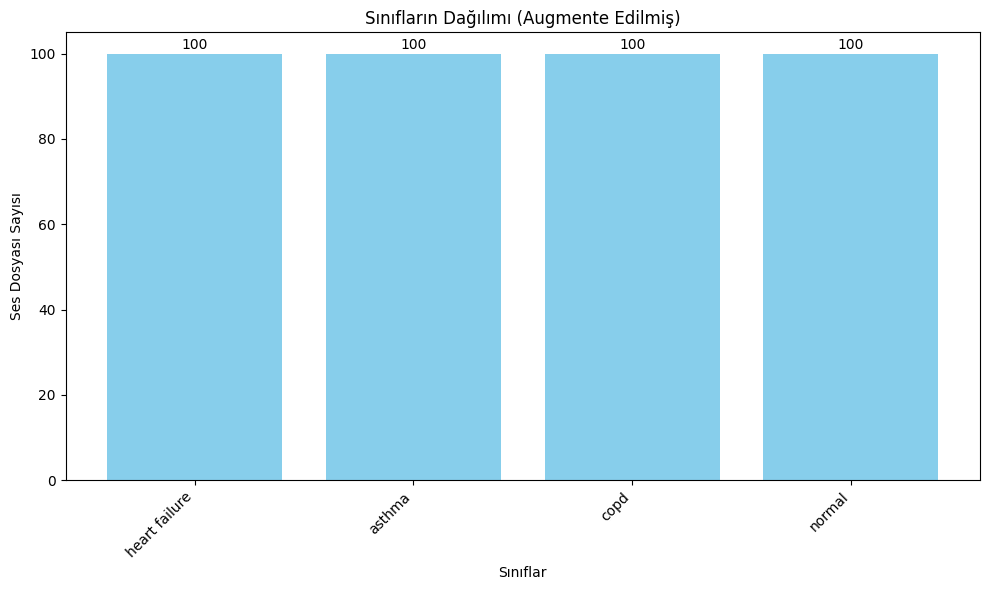

In [ ]:
import matplotlib.pyplot as plt
import os

# Klasör yolu
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"

# Etiketleri saymak için sözlük
u_class_counts = {}

# Dosyaları dolaş
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        file_name = file_name.strip()

        try:
            # Etiketi çıkar (örnek: EP69_pneumonia,Bronchial,P R L ,64,M_aug2.wav -> pneumonia)
            raw_label = file_name.split('_')[1].split(',')[0].strip().lower()

            # Etiketi normalize et
            if 'asthma and lung fibrosis' in raw_label:
                label_name = 'asthma'
            elif 'heart failure + copd' in raw_label or 'heart failure + lung fibrosis' in raw_label:
                label_name = 'heart failure'
            elif 'asthma' in raw_label:
                label_name = 'asthma'
            elif 'bron' in raw_label:
                label_name = 'bron'
            elif 'copd' in raw_label:
                label_name = 'copd'
            elif 'heart failure' in raw_label:
                label_name = 'heart failure'
            elif 'lung fibrosis' in raw_label:
                label_name = 'lung fibrosis'
            elif 'pleural effusion' in raw_label or 'plueral effusion' in raw_label:
                label_name = 'plueral effusion'
            elif 'pneumonia' in raw_label:
                label_name = 'pneumonia'
            elif raw_label == 'n':
                label_name = 'normal'
            else:
                print(f"Bilinmeyen sınıf: {raw_label}")
                continue

            # Sözlüğe ekle
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

        except Exception as e:
            print(f"Hata: {file_name} -> {e}")

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı (Augmente Edilmiş)')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import os
import torch
import torchaudio
import numpy as np

max_len = 1500

def normalize_label(raw_label):
    raw_label = raw_label.lower().strip()
    if 'asthma and lung fibrosis' in raw_label:
        return 'asthma'
    elif 'heart failure + copd' in raw_label or 'heart failure + lung fibrosis' in raw_label:
        return 'heart failure'
    elif 'asthma' in raw_label:
        return 'asthma'
    elif 'copd' in raw_label:
        return 'copd'
    elif 'heart failure' in raw_label:
        return 'heart failure'
    elif raw_label == 'n':
        return 'normal'
    else:
        print(f"Bilinmeyen sınıf: {raw_label}")
        return None

def extract_label_from_filename(file_name):
    try:
        raw_label = file_name.split('_')[1].split(',')[0].strip()
        return normalize_label(raw_label)
    except IndexError:
        print(f"Dosya adı formatı uygun değil: {file_name}")
        return None

def extract_mfcc(file_path, max_len=max_len):
    waveform, sample_rate = torchaudio.load(file_path)

    mfcc_transform = torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=40,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )

    mfcc = mfcc_transform(waveform).squeeze(0)  # (40, time)

    if mfcc.shape[1] < max_len:
        pad_amount = max_len - mfcc.shape[1]
        mfcc = torch.nn.functional.pad(mfcc, (0, pad_amount))
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc.numpy()

# Verisetini yükle (otomatik max_len belirleme + padding)
def load_data_from_folder(folder_path, max_len=max_len):
    X = []
    y = []
    labels_set = set()

    # İlk olarak klasördeki dosyalar üzerinden etiketleri topla
    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is not None:
                labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print(f"Bulunan sınıflar ve indeksleri: {label2idx}")

    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is None:
                continue
            file_path = os.path.join(folder_path, filename)
            mfcc = extract_mfcc(file_path, max_len)
            X.append(mfcc)
            y.append(label2idx[label])

    return np.array(X), np.array(y), label2idx

# Kullanım
train_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
val_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"

X_train, y_train, label2idx = load_data_from_folder(train_folder)
X_val, y_val, _ = load_data_from_folder(val_folder)
X_test, y_test, _ = load_data_from_folder(test_folder)

# CNN için kanal boyutu ekle (N, 40, 751, 1)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]


print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Val data shape: {X_val.shape}, Val labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")


Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
Train data shape: (400, 40, 1500, 1), Train labels shape: (400,)
Val data shape: (42, 40, 1500, 1), Val labels shape: (42,)
Test data shape: (43, 40, 1500, 1), Test labels shape: (43,)


In [ ]:
import os
import re

def get_labels_from_dir(directory):
    labels = []
    files = [f for f in os.listdir(directory) if f.endswith(".wav")]
    for file_name in files:
        match = re.match(
            r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)(?:_aug\d+)?(?:_aug\d+)?\.wav$', file_name
        )
        if match:
            diagnosis = match.group(2).strip().lower()
            # Aynı etiket temizleme mantığını kullan
            if 'asthma and lung fibrosis' in diagnosis:
                cleaned_label = 'asthma'
            elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
                cleaned_label = 'heart failure'
            elif 'asthma' in diagnosis:
                cleaned_label = 'asthma'
            elif 'bron' in diagnosis:
                cleaned_label = 'bron'
            elif 'copd' in diagnosis:
                cleaned_label = 'copd'
            elif 'heart failure' in diagnosis:
                cleaned_label = 'heart failure'
            elif 'lung fibrosis' in diagnosis:
                cleaned_label = 'lung fibrosis'
            elif 'pleural effusion' in diagnosis or 'plueral effusion' in diagnosis:
                cleaned_label = 'plueral effusion'
            elif 'pneumonia' in diagnosis:
                cleaned_label = 'pneumonia'
            elif diagnosis == 'n':
                cleaned_label = 'normal'
            else:
                continue
            labels.append(cleaned_label)
        else:
            print(f"Regex'e uymayan dosya: {file_name}")
    return labels

train_labels = get_labels_from_dir("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4")
val_labels = get_labels_from_dir("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4")
test_labels = get_labels_from_dir("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4")

print(f"Train labels: {train_labels[:10]}")
print(f"Val labels: {val_labels[:10]}")
print(f"Test labels: {test_labels[:10]}")


Train labels: ['heart failure', 'asthma', 'asthma', 'copd', 'normal', 'normal', 'heart failure', 'copd', 'normal', 'normal']
Val labels: ['heart failure', 'asthma', 'asthma', 'asthma', 'asthma', 'normal', 'normal', 'normal', 'normal', 'normal']
Test labels: ['asthma', 'asthma', 'copd', 'copd', 'normal', 'heart failure', 'normal', 'copd', 'normal', 'asthma']


In [ ]:
label_map = {
    'asthma': 0,
    'copd': 1,
    'heart failure': 2,
    'normal': 3
}

# Doğru isimleri kullan
y_train_int = np.array([label_map[label] for label in train_labels])
y_val_int = np.array([label_map[label] for label in val_labels])
y_test_int = np.array([label_map[label] for label in test_labels])

# One-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train_int, num_classes=len(label_map))
y_val = to_categorical(y_val_int, num_classes=len(label_map))
y_test = to_categorical(y_test_int, num_classes=len(label_map))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

num_clases = 4
model = Sequential([
    Input(shape=(40, 1500, 1)),  # Buraya input_shape artık ayrı olarak yazılıyor
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_clases, activation='softmax')  # 4 sınıf
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 1500, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 1500, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 750, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 750, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 750, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 375, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 375, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 375, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 187, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 119680)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    30,638,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,732,932 (117.24 MB)

 Trainable params: 30,732,484 (117.24 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,         # 10 epoch boyunca iyileşme olmazsa dur
    restore_best_weights=True,
    verbose=1
)

# MFCC CNN SONUÇLARI

In [ ]:
# Eğitim
history = model.fit(
    X_train, y_train_int,
    validation_data=(X_val, y_val_int),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 95s 8s/step - accuracy: 0.2961 - loss: 9.9501 - val_accuracy: 0.3810 - val_loss: 2.1508
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 133s 7s/step - accuracy: 0.4447 - loss: 2.5788 - val_accuracy: 0.4286 - val_loss: 1.3883
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - accuracy: 0.5524 - loss: 1.1795 - val_accuracy: 0.4048 - val_loss: 1.2800
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 92s 8s/step - accuracy: 0.5981 - loss: 0.9098 - val_accuracy: 0.3095 - val_loss: 1.2539
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.7226 - loss: 0.6860 - val_accuracy: 0.4286 - val_loss: 1.2423
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - accuracy: 0.7786 - loss: 0.5475 - val_accuracy: 0.5000 - val_loss: 1.1747
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.7899 - loss: 0.4846 - val_accuracy: 0.3333 - val_loss: 1.2954
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 84s 8s/step - accuracy: 0.8666 - loss: 0.3753 - val_accuracy: 0.3810 - 

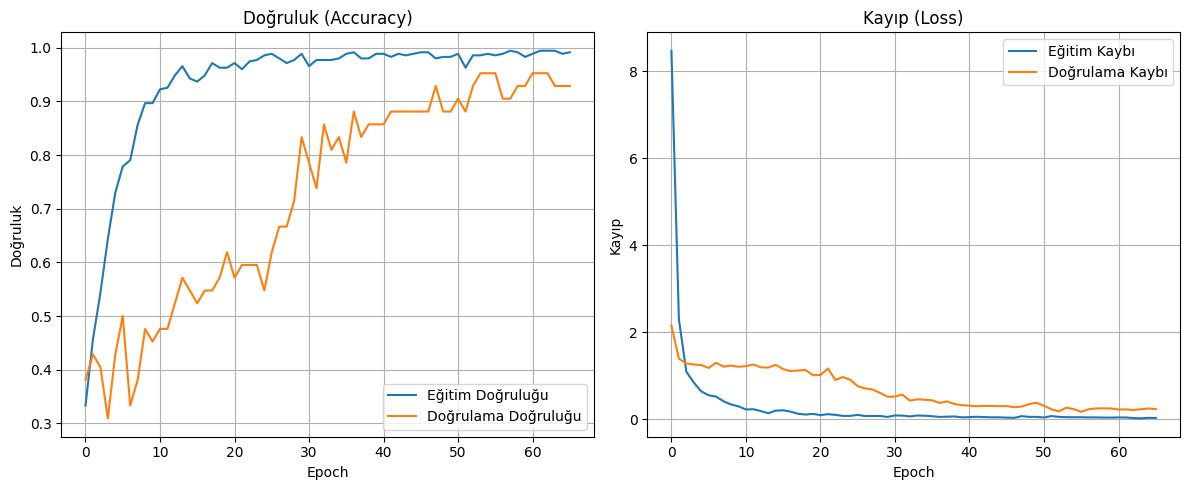

In [ ]:
import matplotlib.pyplot as plt

# Doğruluk grafiği
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Doğruluk (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.grid(True)

# Kayıp (Loss) grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Kayıp (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
target_names = list(label2idx.keys())
print(confusion_matrix(y_true_classes, y_pred_classes))
print(classification_report(y_true_classes, y_pred_classes, target_names=label2idx.keys()))


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
[[12  0  0  3]
 [ 0  4  0  0]
 [ 0  1  5  2]
 [ 0  0  0 16]]
               precision    recall  f1-score   support

       asthma       1.00      0.80      0.89        15
         copd       0.80      1.00      0.89         4
heart failure       1.00      0.62      0.77         8
       normal       0.76      1.00      0.86        16

     accuracy                           0.86        43
    macro avg       0.89      0.86      0.85        43
 weighted avg       0.89      0.86      0.86        43



In [ ]:
import numpy as np

# Gerçek sınıflar (y_test one-hot encoded olduğu için argmax ile dönüştürülüyor)
y_true_classes = np.argmax(y_test, axis=1) # <-- Added this line

# Örnek: y_true_classes: gerçek sınıflar (integer indices), y_pred_classes: tahmin edilen sınıflar (integer indices)

# Yanlış sınıflandırılan örneklerin indekslerini bul
misclassified_idx = np.where(y_true_classes != y_pred_classes)[0] # <-- Changed y_test to y_true_classes

print(f"\nToplam yanlış sınıflandırılan örnek sayısı: {len(misclassified_idx)}\n")

# label2idx sözlüğünün tersini oluşturarak etiket isimlerini yazdır
idx2label = {v: k for k, v in label2idx.items()} # <-- Added this line

for i in misclassified_idx:
    # Tamsayı etiketlerini metin etiketlerine dönüştürerek yazdır
    true_label_name = idx2label[y_true_classes[i]] # <-- Changed y_test[i] and added idx2label
    predicted_label_name = idx2label[y_pred_classes[i]] # <-- Added this line

    print(f"Index {i}: Gerçek = {true_label_name} | Tahmin = {predicted_label_name}")



Toplam yanlış sınıflandırılan örnek sayısı: 6

Index 5: Gerçek = heart failure | Tahmin = normal
Index 16: Gerçek = asthma | Tahmin = normal
Index 21: Gerçek = heart failure | Tahmin = normal
Index 30: Gerçek = asthma | Tahmin = normal
Index 33: Gerçek = heart failure | Tahmin = copd
Index 39: Gerçek = asthma | Tahmin = normal


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_accuracy = model.evaluate(X_test, y_test_int, verbose=1) # Changed y_test to y_test_int
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8653 - loss: 0.6119
Test Loss: 0.6003
Test Accuracy: 0.8605


# Transferlearning

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models
import numpy as np

# ================================
# Early Stopping Sınıfı
# ================================
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.delta = delta
        self.best_model = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = model.state_dict()
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model = model.state_dict()
            self.counter = 0

# ================================
# Dataset Tensorlara Dönüştür
# ================================
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)


y_train_tensor = torch.tensor(y_train_int, dtype=torch.long) # y_train_int kullanıldı ve LongTensor olarak kaydedildi
y_val_tensor = torch.tensor(y_val_int, dtype=torch.long)   # y_val_int kullanıldı ve LongTensor olarak kaydedildi
y_test_tensor = torch.tensor(y_test_int, dtype=torch.long)  # y_test_int kullanıldı ve LongTensor olarak kaydedildi


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ================================
# Model Kurulumu
# ================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(pretrained=True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

num_classes = len(label2idx)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# ================================
# Eğitim Ayarları
# ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 50

# Early Stopping nesnesi
early_stopping = EarlyStopping(patience=5, delta=0.001)

# ================================
# Eğitim Döngüsü
# ================================
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        # CrossEntropyLoss artık LongTensor tipinde ve (batch_size,) şeklinde bir y_batch bekliyor
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    train_acc = 100. * correct / total

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()

    val_acc = 100. * correct / total

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early Stopping kontrolü
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# En iyi modeli geri yükle
model.load_state_dict(early_stopping.best_model)

# ================================
# Test Başarımı
# ================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model(X_batch)
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

test_acc = 100. * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/50 | Train Loss: 15.4079 | Train Acc: 31.90% | Val Loss: 2.7653 | Val Acc: 38.10%
Epoch 2/50 | Train Loss: 12.0478 | Train Acc: 59.20% | Val Loss: 2.6637 | Val Acc: 50.00%
Epoch 3/50 | Train Loss: 9.4510 | Train Acc: 70.98% | Val Loss: 2.0278 | Val Acc: 59.52%
Epoch 4/50 | Train Loss: 6.8870 | Train Acc: 81.03% | Val Loss: 1.9124 | Val Acc: 54.76%
Epoch 5/50 | Train Loss: 4.1839 | Train Acc: 92.53% | Val Loss: 1.4995 | Val Acc: 64.29%
Epoch 6/50 | Train Loss: 2.5766 | Train Acc: 96.26% | Val Loss: 1.2328 | Val Acc: 78.57%
Epoch 7/50 | Train Loss: 1.8102 | Train Acc: 97.99% | Val Loss: 1.3465 | Val Acc: 73.81%
Epoch 8/50 | Train Loss: 1.7420 | Train Acc: 97.70% | Val Loss: 1.7168 | Val Acc: 64.29%
Epoch 9/50 | Train Loss: 1.5102 | Train Acc: 96.84% | Val Loss: 1.2434 | Val Acc: 76.19%
Epoch 10/50 | Train Loss: 0.9665 | Train Acc: 98.28% | Val Loss: 0.8861 | Val Acc: 78.57%
Epoch 11/50 | Train Loss: 0.7370 | Train Acc: 98.85% | Val Loss: 1.0414 | Val Acc: 78.57%
Epoch 12/50 | Tra

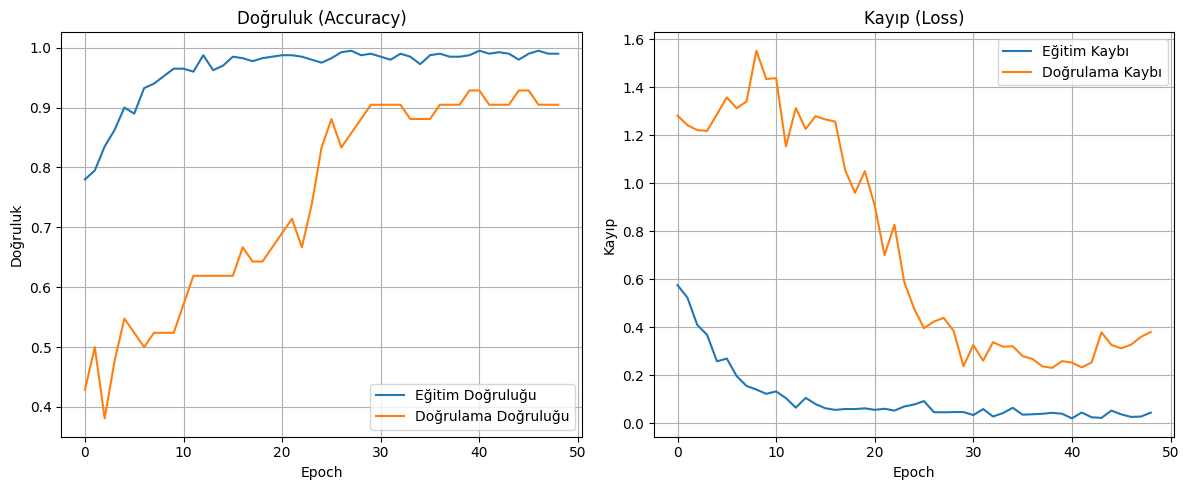

In [ ]:
import matplotlib.pyplot as plt

# Doğruluk grafiği
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Doğruluk (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.grid(True)

# Kayıp (Loss) grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Kayıp (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# 4 SINIFLI MFCC CNN SONUÇLARI

In [ ]:
print(y_train)

[[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0.

In [ ]:
print(y_train_int)

[2 0 0 1 3 3 2 1 3 3 2 1 3 2 0 0 2 0 3 3 3 2 3 2 2 0 3 3 1 1 1 3 3 3 0 2 0
 3 3 0 0 3 1 3 1 1 3 1 3 3 2 0 2 0 0 1 0 0 0 1 3 3 3 1 2 1 3 3 0 3 2 3 2 0
 0 0 3 3 0 1 0 2 3 3 2 1 3 0 3 3 2 2 3 0 2 3 2 3 3 0 2 3 0 2 2 0 2 1 0 0 2
 3 0 0 0 0 0 0 0 0 3 3 0 3 0 3 0 3 0 0 3 3 3 3 1 0 2 3 2 3 0 0 0 0 3 0 2 3
 2 3 2 0 0 2 2 0 2 0 3 0 0 0 0 3 3 0 2 0 2 0 3 3 0 0 0 2 0 3 0 2 2 3 3 3 3
 3 3 3 3 0 0 3 0 1 3 3 3]


In [ ]:
len(y_train_int)

400

In [ ]:
len(X_train)

400

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

num_clases = 4
model = Sequential([
    Input(shape=(40, 1500, 1)),  # Buraya input_shape artık ayrı olarak yazılıyor
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_clases, activation='softmax')  # 4 sınıf
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 1500, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 1500, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 750, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 750, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 750, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 375, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 375, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 375, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 187, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 119680)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    30,638,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,732,932 (117.24 MB)

 Trainable params: 30,732,484 (117.24 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# EarlyStopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,         # 10 epoch boyunca iyileşme olmazsa dur
    restore_best_weights=True,
    verbose=1
)

In [ ]:
print("y_train_int dtype:", y_train_int.dtype)
print("y_train_int example:", y_train_int[:10])
from sklearn.model_selection import train_test_split

# Orijinal veri
print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))


y_train_int dtype: int64
y_train_int example: [2 0 0 1 3 3 2 1 3 3]
Train: 400
Val: 42
Test: 43


In [ ]:
# Eğitim
history = model.fit(
    X_train, y_train_int,
    validation_data=(X_val, y_val_int),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 97s 7s/step - accuracy: 0.8058 - loss: 0.5588 - val_accuracy: 0.4286 - val_loss: 1.2816
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 140s 7s/step - accuracy: 0.8019 - loss: 0.4978 - val_accuracy: 0.5000 - val_loss: 1.2418
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 144s 7s/step - accuracy: 0.8588 - loss: 0.3756 - val_accuracy: 0.3810 - val_loss: 1.2211
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 94s 7s/step - accuracy: 0.8756 - loss: 0.3740 - val_accuracy: 0.4762 - val_loss: 1.2176
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.9015 - loss: 0.2424 - val_accuracy: 0.5476 - val_loss: 1.2869
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 141s 7s/step - accuracy: 0.8897 - loss: 0.2593 - val_accuracy: 0.5238 - val_loss: 1.3572
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 146s 7s/step - accuracy: 0.9225 - loss: 0.2191 - val_accuracy: 0.5000 - val_loss: 1.3120
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.9419 - loss: 0.1617 - val_accuracy: 0.52

In [ ]:
print(y_test)

[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


In [ ]:
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)


y_test shape: (43, 4)
y_pred shape: (43, 4)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# One-hot encoded y_test'i label formata çevir
y_val_labels = np.argmax(y_val, axis=1)
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix ve Classification Report
print(confusion_matrix(y_val_labels, y_pred_classes))
print(classification_report(y_val_labels, y_pred_classes, target_names=label2idx.keys()))



2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step   
[[13  0  1  0]
 [ 0  4  0  0]
 [ 0  0  7  1]
 [ 0  0  2 14]]
               precision    recall  f1-score   support

       asthma       1.00      0.93      0.96        14
         copd       1.00      1.00      1.00         4
heart failure       0.70      0.88      0.78         8
       normal       0.93      0.88      0.90        16

     accuracy                           0.90        42
    macro avg       0.91      0.92      0.91        42
 weighted avg       0.92      0.90      0.91        42



In [ ]:
model.save("4sınıflıCNN.keras")

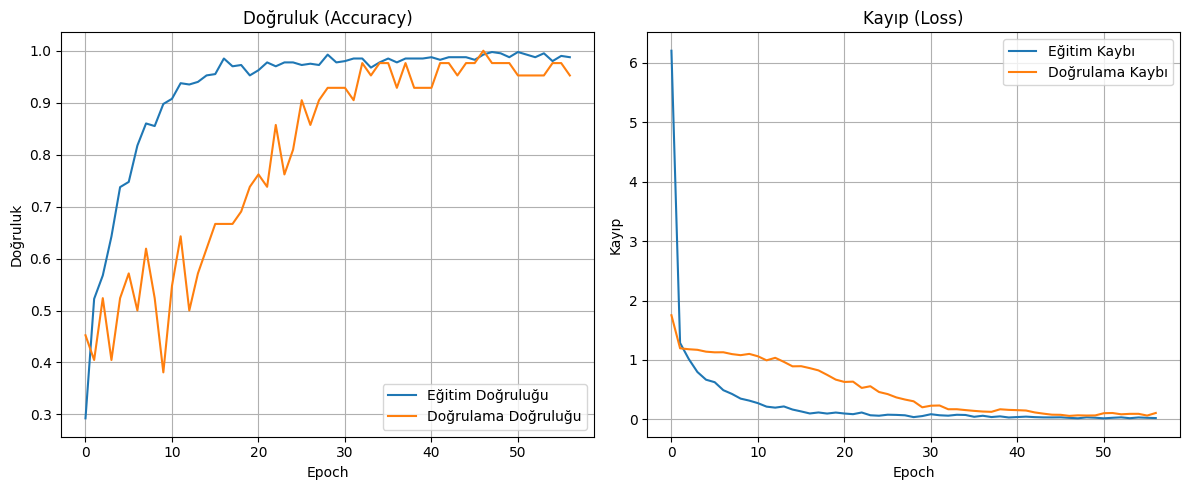

In [ ]:
import matplotlib.pyplot as plt

# Doğruluk grafiği
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.title('Doğruluk (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.grid(True)

# Kayıp (Loss) grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Kayıp (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes, target_names=label2idx.keys()))


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
[[14  0  0  1]
 [ 0  4  0  0]
 [ 0  0  6  2]
 [ 0  0  0 16]]
               precision    recall  f1-score   support

       asthma       1.00      0.93      0.97        15
         copd       1.00      1.00      1.00         4
heart failure       1.00      0.75      0.86         8
       normal       0.84      1.00      0.91        16

     accuracy                           0.93        43
    macro avg       0.96      0.92      0.93        43
 weighted avg       0.94      0.93      0.93        43



Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}

In [ ]:
import numpy as np


misclassified_idx = np.where(y_test != y_pred_classes)[0]

print(f"\nToplam yanlış sınıflandırılan örnek sayısı: {len(misclassified_idx)}\n")

for i in misclassified_idx:
    print(f"Index {i}: Gerçek = {y_test[i]} | Tahmin = {y_pred_classes[i]}")



Toplam yanlış sınıflandırılan örnek sayısı: 3

Index 5: Gerçek = 2 | Tahmin = 3
Index 21: Gerçek = 2 | Tahmin = 3
Index 30: Gerçek = 0 | Tahmin = 3


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 669ms/step - accuracy: 0.9222 - loss: 0.3231
Test Loss: 0.2948
Test Accuracy: 0.9302


#TRANSFER LEARNİNG RESNET18

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models
import numpy as np

# ================================
# Early Stopping Sınıfı
# ================================
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.delta = delta
        self.best_model = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = model.state_dict()
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model = model.state_dict()
            self.counter = 0

# ================================
# Dataset Tensorlara Dönüştür
# ================================
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

y_train_tensor = torch.tensor(y_train_int, dtype=torch.long) # y_train_int kullanıldı ve LongTensor olarak kaydedildi
y_val_tensor = torch.tensor(y_val_int, dtype=torch.long)   # y_val_int kullanıldı ve LongTensor olarak kaydedildi
y_test_tensor = torch.tensor(y_test_int, dtype=torch.long)  # y_test_int kullanıldı ve LongTensor olarak kaydedildi


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ================================
# Model Kurulumu
# ================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(pretrained=True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

num_classes = len(label2idx)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# ================================
# Eğitim Ayarları
# ================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 50

# Early Stopping nesnesi
early_stopping = EarlyStopping(patience=5, delta=0.001)

# ================================
# Eğitim Döngüsü
# ================================
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        # CrossEntropyLoss artık LongTensor tipinde ve (batch_size,) şeklinde bir y_batch bekliyor
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

    train_acc = 100. * correct / total

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()

    val_acc = 100. * correct / total

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early Stopping kontrolü
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# En iyi modeli geri yükle
model.load_state_dict(early_stopping.best_model)

# ================================
# Test Başarımı
# ================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model(X_batch)
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()

test_acc = 100. * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


Epoch 1/50 | Train Loss: 17.1355 | Train Acc: 39.75% | Val Loss: 2.5133 | Val Acc: 47.62%
Epoch 2/50 | Train Loss: 13.2647 | Train Acc: 56.25% | Val Loss: 2.1135 | Val Acc: 57.14%
Epoch 3/50 | Train Loss: 10.5215 | Train Acc: 73.00% | Val Loss: 2.1336 | Val Acc: 35.71%
Epoch 4/50 | Train Loss: 7.2896 | Train Acc: 83.00% | Val Loss: 1.5948 | Val Acc: 61.90%
Epoch 5/50 | Train Loss: 5.0106 | Train Acc: 90.25% | Val Loss: 1.4673 | Val Acc: 64.29%
Epoch 6/50 | Train Loss: 2.8122 | Train Acc: 95.50% | Val Loss: 1.2649 | Val Acc: 71.43%
Epoch 7/50 | Train Loss: 1.7636 | Train Acc: 98.00% | Val Loss: 1.0853 | Val Acc: 73.81%
Epoch 8/50 | Train Loss: 1.1975 | Train Acc: 98.75% | Val Loss: 0.9902 | Val Acc: 71.43%
Epoch 9/50 | Train Loss: 0.8457 | Train Acc: 99.25% | Val Loss: 0.8821 | Val Acc: 80.95%
Epoch 10/50 | Train Loss: 0.8752 | Train Acc: 98.50% | Val Loss: 1.0807 | Val Acc: 73.81%
Epoch 11/50 | Train Loss: 0.9976 | Train Acc: 98.25% | Val Loss: 1.3261 | Val Acc: 69.05%
Epoch 12/50 | Tr

In [ ]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / total
    test_accuracy = 100 * correct / total
    return avg_test_loss, test_accuracy


In [ ]:
test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 0.8615
Test Accuracy: 76.74%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())


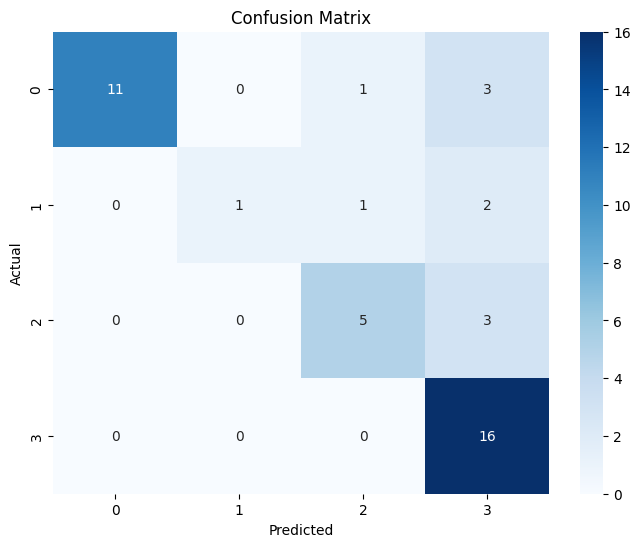

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names=list(label2idx.keys()))
print("Classification Report:\n", report)


Classification Report:
                precision    recall  f1-score   support

       asthma       1.00      0.73      0.85        15
         copd       1.00      0.25      0.40         4
heart failure       0.71      0.62      0.67         8
       normal       0.67      1.00      0.80        16

     accuracy                           0.77        43
    macro avg       0.85      0.65      0.68        43
 weighted avg       0.82      0.77      0.75        43



# TRANSFER LEARNİNG VGG16

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Modeli yükle
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Eğer GPU kullanıyorsan
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg16 = vgg16.to(device)

# İlk katmanları dondur
for param in vgg16.features.parameters():
    param.requires_grad = False


output_classes = 4
vgg16.classifier[6] = nn.Linear(4096, output_classes)

vgg16 = vgg16.to(device)

# Loss ve optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16.parameters(), lr=0.0001)
num_epochs = 50

In [ ]:
from torchvision import transforms

# VGG16 için gerekli transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # 1 kanaldan 3 kanala çıkar
])

# Dataset tanımı örnek:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label

# Dataset ve Dataloader tanımla
train_dataset = CustomDataset(X_train, y_train_int, transform=transform)
val_dataset = CustomDataset(X_val, y_val_int, transform=transform)


train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)


In [ ]:
print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train_int.shape}")
print(f"Val data shape: {X_val.shape}, Val labels shape: {y_val_int.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test_int.shape}")


Train data shape: (400, 40, 1500, 1), Train labels shape: (400,)
Val data shape: (42, 40, 1500, 1), Val labels shape: (42,)
Test data shape: (43, 40, 1500, 1), Test labels shape: (43,)


Epoch 1/20 | Train Loss: 2.4930 Acc: 28.75% | Val Loss: 1.4491 Acc: 26.19%
Epoch 2/20 | Train Loss: 1.4498 Acc: 33.75% | Val Loss: 1.3353 Acc: 26.19%
Epoch 3/20 | Train Loss: 1.3401 Acc: 35.50% | Val Loss: 1.2685 Acc: 23.81%
Epoch 4/20 | Train Loss: 1.3120 Acc: 33.75% | Val Loss: 1.2438 Acc: 35.71%
Epoch 5/20 | Train Loss: 1.2384 Acc: 44.00% | Val Loss: 1.2397 Acc: 35.71%
Epoch 6/20 | Train Loss: 1.1884 Acc: 44.00% | Val Loss: 1.2776 Acc: 30.95%
Epoch 7/20 | Train Loss: 1.1508 Acc: 50.00% | Val Loss: 1.1682 Acc: 40.48%
Epoch 8/20 | Train Loss: 1.1348 Acc: 53.75% | Val Loss: 1.1393 Acc: 50.00%
Epoch 9/20 | Train Loss: 1.1174 Acc: 53.50% | Val Loss: 1.0755 Acc: 52.38%
Epoch 10/20 | Train Loss: 1.0553 Acc: 56.50% | Val Loss: 1.0716 Acc: 61.90%
Epoch 11/20 | Train Loss: 1.1323 Acc: 50.75% | Val Loss: 1.2484 Acc: 35.71%
Epoch 12/20 | Train Loss: 1.0168 Acc: 59.50% | Val Loss: 1.1530 Acc: 38.10%
Epoch 13/20 | Train Loss: 1.0405 Acc: 54.00% | Val Loss: 1.0321 Acc: 61.90%
Epoch 14/20 | Train L

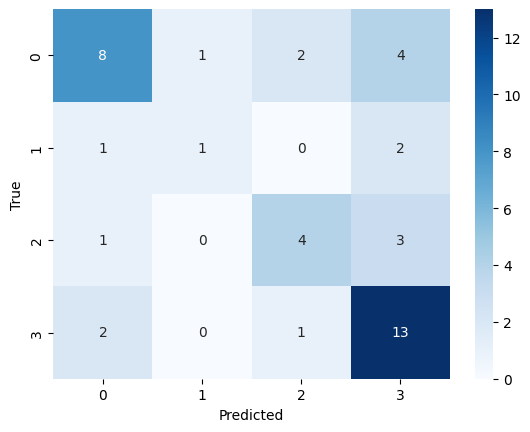

               precision    recall  f1-score   support

       asthma       0.67      0.53      0.59        15
         copd       0.50      0.25      0.33         4
heart failure       0.57      0.50      0.53         8
       normal       0.59      0.81      0.68        16

     accuracy                           0.60        43
    macro avg       0.58      0.52      0.54        43
 weighted avg       0.61      0.60      0.59        43



In [ ]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# ======================
# Custom Dataset
# ======================
class SpectrogramDataset(Dataset):
    def __init__(self, X, y):
        """
        X: NumPy array, shape (N, 40, 1500, 1)
        y: NumPy array, shape (N,)
        """
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # 1) Al ve NumPy -> Torch Tensor
        x = torch.tensor(self.X[idx], dtype=torch.float32)  # (40,1500,1)
        x = x.permute(2, 0, 1)                              # (1,40,1500)

        # 2) Kanalı 3'e çıkar (tek kanalı RGB yapar gibi kopyala)
        x = x.repeat(3, 1, 1)                               # (3,40,1500)

        # 3) 224x224'e yeniden boyutlandır
        x = x.unsqueeze(0)  # batch-dummy: (1,3,40,1500)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        x = x.squeeze(0)    # (3,224,224)

        # 4) Etiket
        label = torch.tensor(self.y[idx], dtype=torch.long)

        return x, label

# ======================
# Verileri TensorDataset’a Hazırla
# ======================

train_dataset = SpectrogramDataset(X_train, y_train_int)
val_dataset   = SpectrogramDataset(X_val,   y_val_int)
test_dataset  = SpectrogramDataset(X_test,  y_test_int)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# ======================
# VGG16 Modeli (Transfer Learning)
# ======================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
# Özelleştir: sadece özellik çıkarma kısmını dondur
for param in vgg16.features.parameters():
    param.requires_grad = False

# Çıkış katmanını sınıf sayısına göre değiştir
num_classes = len(label_map)  # örn. 4
vgg16.classifier[6] = nn.Linear(4096, num_classes)
vgg16 = vgg16.to(device)

# ======================
# Eğitim Ayarları
# ======================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.parameters(), lr=1e-4)
num_epochs = 20

# Early stopping vb. istersen ekleyebilirsin

# ======================
# Eğitim Döngüsü
# ======================
for epoch in range(num_epochs):
    vgg16.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc  = running_corrects / len(train_loader.dataset) * 100

    # Validation
    vgg16.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg16(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            val_corrects += (preds == labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_epoch_acc  = val_corrects / len(val_loader.dataset) * 100

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"| Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% "
          f"| Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}%")

# ======================
# Test Değerlendirme
# ======================
vgg16.eval()
test_correct = 0
total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vgg16(inputs)
        preds = outputs.argmax(dim=1)

        total += labels.size(0)
        test_correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

test_acc = test_correct / total * 100
print(f"Test Accuracy: {test_acc:.2f}%")

# Confusion matrix ve rapor
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(all_labels, all_preds,
      target_names=list(label_map.keys())))


# 4 sınıflı CNN-RNN

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import tensorflow as tf

# K değerini seç (örnek: 5)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Verilerin numpy formatında olduğunu varsayıyoruz:
# X.shape -> (n_samples, features...)
# y.shape -> (n_samples,)
# Eğer y one-hot encoded ise, önce argmax ile tekil hale getir:
# y_single = np.argmax(y, axis=1)  # Sadece one-hot için gerekliyse

fold_no = 1
for train_index, val_index in kfold.split(X, y):  # y one-hot değilse doğrudan kullanılabilir
    print(f"\n===== Fold {fold_no} =====")

    # Verileri ayır
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Modeli sıfırdan oluştur (her fold'da yeniden tanımlanmalı)
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=X.shape[1:]),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(len(np.unique(y)), activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',  # y one-hot değilse bunu kullan
                  metrics=['accuracy'])

    # EarlyStopping opsiyonel
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Eğitimi başlat
    model.fit(X_train, y_trai_int,
              validation_data=(X_val, y_val_int),
              epochs=50,
              batch_size=32,
              callbacks=[early_stopping],
              verbose=1)

    # Değerlendirme
    y_pred = model.predict(X_val)
    y_pred_labels = np.argmax(y_pred, axis=1)

    print("Classification Report:")
    print(classification_report(y_val, y_pred_labels))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred_labels))

    fold_no += 1


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout,
    Reshape, Bidirectional, LSTM, Dense, Flatten
)
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(40, 1500, 1)),  # (n_mfcc, zaman, kanal)

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # CNN çıktılarını RNN'e uygun forma sok
    Reshape((-1, 128)),  # Zaman adımı sayısı x özellik sayısı

    # Bidirectional LSTM katmanı
    Bidirectional(LSTM(64, return_sequences=False)),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 sınıf için
])

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 40, 1500, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 40, 1500, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 20, 750, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 20, 750, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 20, 750, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 10, 375, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 10, 375, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 10, 375, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 5, 187, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 935, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,412 (818.02 KB)

 Trainable params: 208,964 (816.27 KB)

 Non-trainable params: 448 (1.75 KB)

# 4 sınıflı CNN-RNN sonuçları


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbackler
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,          # 10 epoch boyunca val_loss iyileşmezse durdur
    restore_best_weights=True
)

checkpoint = ModelCheckpoint('4sınıflı_best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)



reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Öğrenme oranını 0.5 ile çarp
    patience=5,           # 5 epoch boyunca iyileşme olmazsa
    min_lr=1e-6,
    verbose=1
)

# Hiperparametreler
batch_size = 32
epochs = 100
learning_rate = 0.001

# Optimizer ( Adam)
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Modeli eğit
history = model.fit(
    X_train, y_train_int,
    validation_data=(X_val, y_val_int),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=2
)


Epoch 1/100

Epoch 1: val_loss improved from inf to 1.39487, saving model to 4sınıflı_best_model.keras
13/13 - 116s - 9s/step - accuracy: 0.2550 - loss: 1.4182 - val_accuracy: 0.2857 - val_loss: 1.3949 - learning_rate: 1.0000e-03
Epoch 2/100

Epoch 2: val_loss did not improve from 1.39487
13/13 - 140s - 11s/step - accuracy: 0.3425 - loss: 1.3638 - val_accuracy: 0.1667 - val_loss: 1.4202 - learning_rate: 1.0000e-03
Epoch 3/100

Epoch 3: val_loss improved from 1.39487 to 1.39360, saving model to 4sınıflı_best_model.keras
13/13 - 106s - 8s/step - accuracy: 0.3650 - loss: 1.3339 - val_accuracy: 0.3571 - val_loss: 1.3936 - learning_rate: 1.0000e-03
Epoch 4/100

Epoch 4: val_loss improved from 1.39360 to 1.38399, saving model to 4sınıflı_best_model.keras
13/13 - 106s - 8s/step - accuracy: 0.3650 - loss: 1.3404 - val_accuracy: 0.4048 - val_loss: 1.3840 - learning_rate: 1.0000e-03
Epoch 5/100

Epoch 5: val_loss improved from 1.38399 to 1.35722, saving model to 4sınıflı_best_model.keras
13/13 -

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Reshape, GRU, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

input_shape = (40, 1500, 1)  # örnek MFCC shape (time_steps, n_mfcc, 1), seninkine göre değiştir

inputs = Input(shape=input_shape)

# --- CNN BLOK ---
x = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)  # --> (20, 750, 16)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)  # --> (10, 375, 32)

# --- RNN BLOK ---
# Sadeleştirmek için zaman boyutunu yeniden şekillendir
x = Reshape((375, 320))(x)  # 10*32=320 kanal; (10, 750, 32) --> (750, 320)

# GRU Katmanı (tek yönlü)
x = GRU(64, return_sequences=False)(x)  # sadece son çıktıyı alıyoruz

# --- Dense BLOK ---
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)  # 4 sınıf

model = Model(inputs=inputs, outputs=outputs)

# --- Derleme ---
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 40, 1500, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 40, 1500, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 40, 1500, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 20, 750, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 20, 750, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 20, 750, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 10, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 375, 320)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,524 (326.27 KB)

 Trainable params: 83,428 (325.89 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks tanımı
early_stop = EarlyStopping(
    monitor='val_loss',      # doğrulama kaybına göre takip
    patience=10,             # 10 epoch boyunca iyileşme yoksa durur
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # learning rate'i yarıya indir
    patience=5,              # 5 epoch boyunca iyileşme olmazsa
    min_lr=1e-6,             # minimum öğrenme oranı
    verbose=1
)

checkpoint = ModelCheckpoint(
    '4_cnn_rnn_best_model.keras',  # en iyi modeli kaydeder
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Model eğitimi
history = model.fit(
    X_train, y_train_int,
    validation_data=(X_val, y_val_int),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2664 - loss: 1.3844
Epoch 1: val_loss improved from inf to 1.37815, saving model to 4_cnn_rnn_best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.2661 - loss: 1.3846 - val_accuracy: 0.3810 - val_loss: 1.3782 - learning_rate: 2.5000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2554 - loss: 1.3875
Epoch 2: val_loss improved from 1.37815 to 1.37129, saving model to 4_cnn_rnn_best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2557 - loss: 1.3874 - val_accuracy: 0.2619 - val_loss: 1.3713 - learning_rate: 2.5000e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2339 - loss: 1.3864
Epoch 3: val_loss did not improve from 1.37129
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2339 - loss: 1.3864 - val_accuracy: 0.2857 - val_loss: 1.3779 - learning_rate: 2.5000e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3032 - loss: 1.3827
Ep

# Yeni Bölüm

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import re # re modülünü içe aktarın

# Orijinal dosyaların bulunduğu klasör
original_path = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/trainmel"
val_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/valmel"
test_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/testmel"

# Oluşturulacak dizinleri hazırla
for directory in [train_dir, val_dir, test_dir]:
    os.makedirs(directory, exist_ok=True)

# Klasördeki tüm ses dosyalarını al
files = [f for f in os.listdir(original_path) if f.endswith(".wav")]

# Gerçek diagnosis etiketlerini çıkar
# Bu kısım, dosya isimlerinden diagnosis bilgisini doğru şekilde çıkarmalıdır.
# Önceki hücrelerde kullanılan regex'i veya parsing mantığını buraya taşıyın.
labels = []
processed_files = [] # Sadece başarıyla etiketlenen dosyaları tutmak için

for file_name in files:
    # Önceki hücrelerde kullandığınız regex'i buraya ekleyin
    # Regex'i dosya formatına göre ayarlamanız gerekebilir
    match = re.match(
            r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)(?:_aug\d+)?\.wav$', file_name
        )
    if match:
        diagnosis = match.group(2).strip().lower() # Diagnosis'i küçük harfe çevir

        # Diagnosis etiketlerini temizleme ve birleştirme mantığını buraya ekleyin
        # Önceki hücrelerde 'asthma and lung fibrosis' -> 'asthma' gibi yapılanları buraya taşıyın
        if 'asthma and lung fibrosis' in diagnosis:
            cleaned_label = 'asthma'
        elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
            cleaned_label = 'heart failure'
        elif 'asthma' in diagnosis:
            cleaned_label = 'asthma'
        elif 'bron' in diagnosis:
            cleaned_label = 'bron'
        elif 'copd' in diagnosis:
            cleaned_label = 'copd'
        elif 'heart failure' in diagnosis:
            cleaned_label = 'heart failure'
        elif 'lung fibrosis' in diagnosis:
            cleaned_label = 'lung fibrosis'
        elif 'pleural effusion' in diagnosis or 'plueral effusion' in diagnosis:
            cleaned_label = 'plueral effusion'
        elif 'pneumonia' in diagnosis:
            cleaned_label = 'pneumonia'
        elif diagnosis == 'n':
             cleaned_label = 'normal' # 'n' etiketini 'normal' olarak kullanıyorsanız
        else:
            print(f"Bilinmeyen sınıf: {diagnosis} için dosya {file_name} atlanıyor.")
            continue # Bilinmeyen etiketleri atla

        labels.append(cleaned_label)
        processed_files.append(file_name) # Etiketlenen dosyayı listeye ekle
    else:
        # Regex'e uymayan orijinal dosyaları atla
        print(f"Regex'e uymayan dosya atlanıyor: {file_name}")


# Yeterli sayıda örneği olmayan sınıfları kontrol edin
from collections import Counter
label_counts = Counter(labels)
single_sample_classes = [label for label, count in label_counts.items() if count < 2]

if single_sample_classes:
    print(f"Uyarı: Aşağıdaki sınıflarda yeterli sayıda örnek (en az 2) yok, stratifikasyon bu sınıflar için tam yapılamayabilir veya hata verebilir: {single_sample_classes}")
    # Bu sınıfların dosyalarını ve etiketlerini filtreleyebilirsiniz veya
    # stratify=None kullanabilirsiniz, ancak bu durumda dağılım garanti edilmez.
    # Burada, en az 2 örneği olan sınıflarla devam etme varsayımıyla ilerliyoruz.
    # Eğer sorun devam ederse, bu sınıfları hariç tutmanız gerekebilir.


# Train/val/test ayır
# processed_files ve labels listelerini kullanın, çünkü sadece başarıyla etiketlenen dosyalar dahil edildi.
# train_test_split'in ilk adımı için stratify olarak labels kullanın
# Not: Eğer single_sample_classes listesi boş değilse, stratify hatası alabilirsiniz.
# Bu durumda, o sınıfları manuel olarak ayırmayı veya stratify=None kullanmayı düşünebilirsiniz.
try:
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        processed_files, labels, test_size=0.3, stratify=labels, random_state=42
    )

    # temp_files ve temp_labels'ı val ve test olarak ayır
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42 # temp_labels ile stratify edin
    )
except ValueError as e:
     print(f"Hata: Veri bölme sırasında stratifikasyon hatası oluştu: {e}")
     print("Lütfen tek örneği olan sınıfları kontrol edin veya stratifikasyon stratejisini gözden geçirin.")
     # Burada daha fazla hata işleme veya alternatif bölme stratejisi eklenebilir.
     # Örneğin, stratify=None ile tekrar deneyebilir veya soruna neden olan sınıfları manuel olarak ele alabilirsiniz.
     exit() # Hata durumunda betiği sonlandır

print(f"Eğitim dosyası sayısı: {len(train_files)}")
print(f"Doğrulama dosyası sayısı: {len(val_files)}")
print(f"Test dosyası sayısı: {len(test_files)}")


# Kopyala
for f in train_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(train_dir, f))
for f in val_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(val_dir, f))
for f in test_files:
    shutil.copy(os.path.join(original_path, f), os.path.join(test_dir, f))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files'